In [45]:
import matplotlib.pyplot as plt
import numpy as np
import qiskit_aer
import scipy.constants as constants
from qiskit import transpile
from qiskit.circuit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, partial_trace
from qiskit_aer_encore.simulator import generate_aer_simulator
from qiskit_hamiltonian_simulation.time_independent.direct import (
    MomentumDomainEvolutionQuadratic,
    PositionDomainEvolutionQuadratic,
)
from qiskit_hamiltonian_simulation.time_independent.sample_based import (
    KineticEvolutionSampleBased,
    PotentialEvolutionSampleBased,
)
from qiskit_phase_propagator.sample_based import (
    QuadraticSignalSampleBasedPhasePropagator,
)
from qiskit_signals.helper_types import EncodingType
from qiskit_signals.quantum_axis import (
    AngularWavenumberAxis,
    MomentumAxis,
    PositionAxis,
)
from qiskit_signals.quantum_signal import GenericQuantumSignal, QuadraticQuantumSignal
from qiskit_signals.sample_based_signal import ArbitrarySignalForSampleBasedProtocol
from wave_optics_propagation.elements import (
    free_space_signal_generator,
    radius_of_convex_planar_lens_as_a_func_of_z,
    thin_lens_signal_generator,
    thin_transparent_plate_signal_generator,
)

In [46]:
def plot_wavefunction(psi, plot_size_scale=1, normalize=True):
    abs_part = np.abs(psi)
    if normalize:
        abs_part = abs_part / np.linalg.norm(abs_part)
    phase_part = np.angle(psi)

    num_of_basis = len(abs_part)
    num_of_qubits = (num_of_basis - 1).bit_length()
    x_axis = np.arange(num_of_basis)

    # ket_labels = [
    #     rf"$|{np.binary_repr(x, width=num_of_qubits)}\rangle$" for x in x_axis
    # ]
    # example:
    # KET_LABELS = [r'$|000\rangle$', r'$|001\rangle$', r'$|010\rangle$', r'$|011\rangle$', r'$|100\rangle$', r'$|101\rangle$', r'$|110\rangle$', r'$|111\rangle$']

    PHASE_LABELS = [
        r"$-\pi$",
        r"$-\frac{3\pi}{4}$",
        r"$-\frac{\pi}{2}$",
        r"$-\frac{\pi}{4}$",
        r"$0$",
        r"$\frac{\pi}{4}$",
        r"$\frac{\pi}{2}$",
        r"$\frac{3\pi}{4}$",
        r"$\pi$",
    ]

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(2 * 6.4 * plot_size_scale, 1 * 4.8 * plot_size_scale)
    )
    ax1.plot(abs_part)
    ax2.plot(phase_part)
    ax2.set_ylim(-np.pi - 0.3, np.pi + 0.3)

    # ax1.set_xticks(x_axis, ket_labels, rotation=45)
    # ax2.set_xticks(x_axis, ket_labels, rotation=45)

    ax2.set_yticks(
        [
            -np.pi,
            -np.pi * 3 / 4,
            -np.pi / 2,
            -np.pi / 4,
            0,
            np.pi / 4,
            np.pi / 2,
            np.pi * 3 / 4,
            np.pi,
        ]
    )
    ax2.set_yticklabels(PHASE_LABELS)

    ax1.set_xlabel(r"$|x\rangle$")
    ax2.set_xlabel(r"$|x\rangle$")

    ax1.set_ylabel(r"$|\psi(x)|$")
    ax2.set_ylabel(r"$\angle\psi(x)$")

In [47]:
num_qubits = 8
dimension = 2**num_qubits
max_delta = 0.1

In [ ]:
wavelength = 550e-9
k_0 = 2 * constants.pi / wavelength
hbar = constants.hbar
c = constants.c

In [49]:
delta_x = 1 / dimension

In [50]:
x_axis = PositionAxis(
    num_qubits=num_qubits, delta_x=delta_x, encoding=EncodingType.UNSIGNED
)
p_axis = MomentumAxis.from_position_axis(x_axis, hbar=hbar)
k_axis = AngularWavenumberAxis.from_position_axis(x_axis)

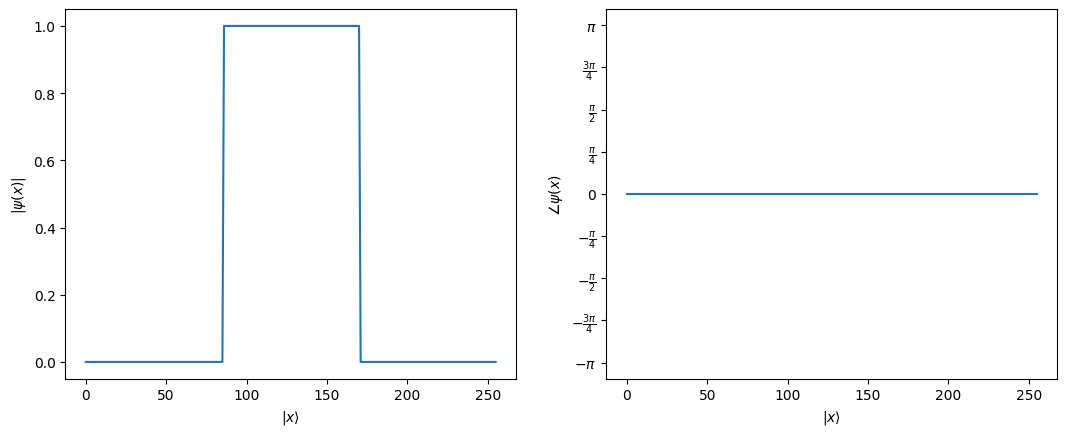

In [51]:
# def psi_signal_function(x):
#     sigma = 1 / 20
#     mu = 1 / 2
#     norm_factor = 1 / (sigma * (2 * constants.pi) ** 0.25)
#     return norm_factor * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def psi_signal_function(x):
    return np.where(
        (x > 1 / 3) & (x < 2 / 3),
        1,
        0,
    )


# def psi_signal_function(x):
#     signal = np.zeros(dimension)
#     middle = dimension // 2
#     signal[middle - 20 : middle - 15] = 1
#     signal[middle + 15 : middle + 20] = 1
#     return signal


psi = GenericQuantumSignal(x_axis, psi_signal_function)
plot_wavefunction(psi.data, normalize=False)


In [52]:
lens_thickness = 0.02
lens_width = 1.0
focal_length = 30
lens_slices = 20
lens_slice_positions = np.linspace(0, lens_thickness, lens_slices, endpoint=False)
lens_slice_thickness = lens_thickness / lens_slices
refractive_index = 1.5

distance_to_simulate_after_lens = 0.1
num_of_steps_after_lens = 40
step_size_after_lens = distance_to_simulate_after_lens / num_of_steps_after_lens

In [53]:
lens_lengths = [
    radius_of_convex_planar_lens_as_a_func_of_z(focal_length, z, lens_thickness)
    for z in lens_slice_positions
]
lens_lengths

[np.float64(0.0),
 np.float64(0.24494693302848608),
 np.float64(0.3464043879628273),
 np.float64(0.4242534619775927),
 np.float64(0.48988161835289296),
 np.float64(0.5476997352563756),
 np.float64(0.5999699992499549),
 np.float64(0.6480362644174188),
 np.float64(0.692774133466278),
 np.float64(0.7347918072488658),
 np.float64(0.7745321168292816),
 np.float64(0.8123293666979746),
 np.float64(0.848443280367079),
 np.float64(0.8830804040403446),
 np.float64(0.9164082059868071),
 np.float64(0.9485647052257904),
 np.float64(0.9796652489498068),
 np.float64(1.0098074073801973),
 np.float64(1.0390745882755785),
 np.float64(1.0675387580785414)]

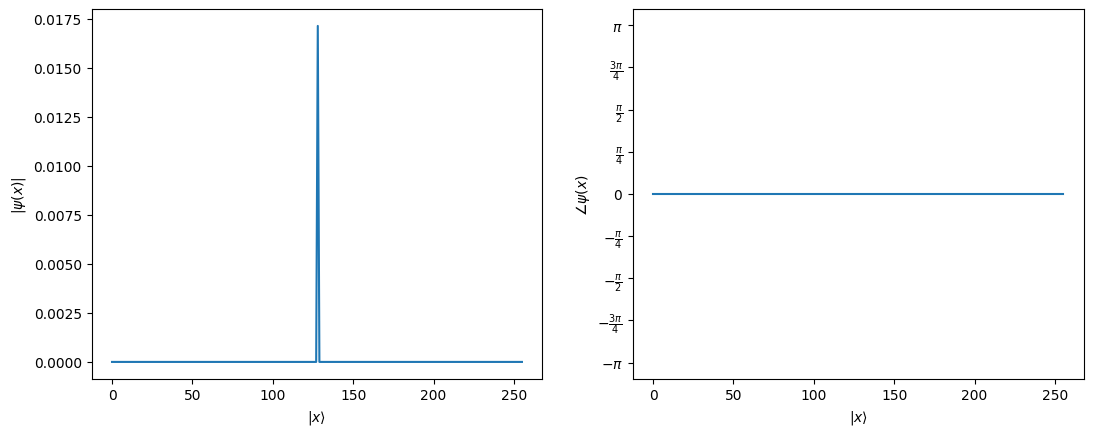

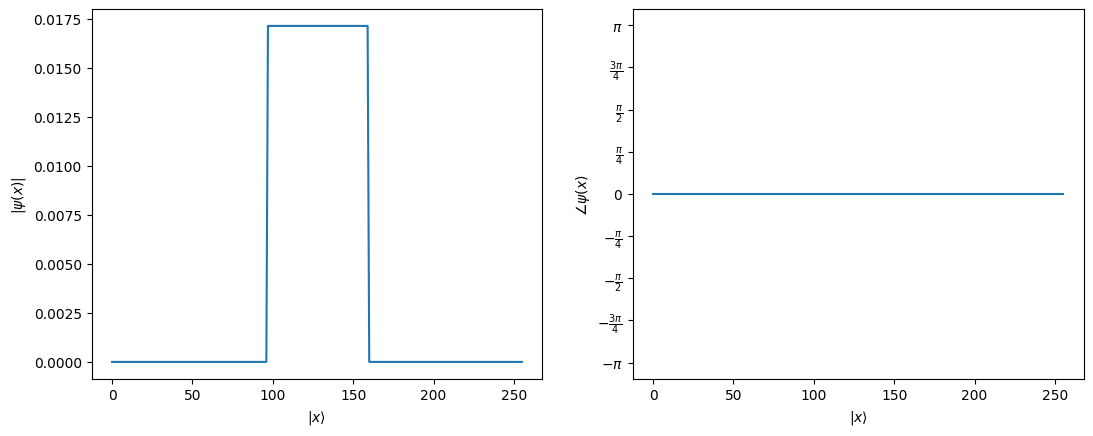

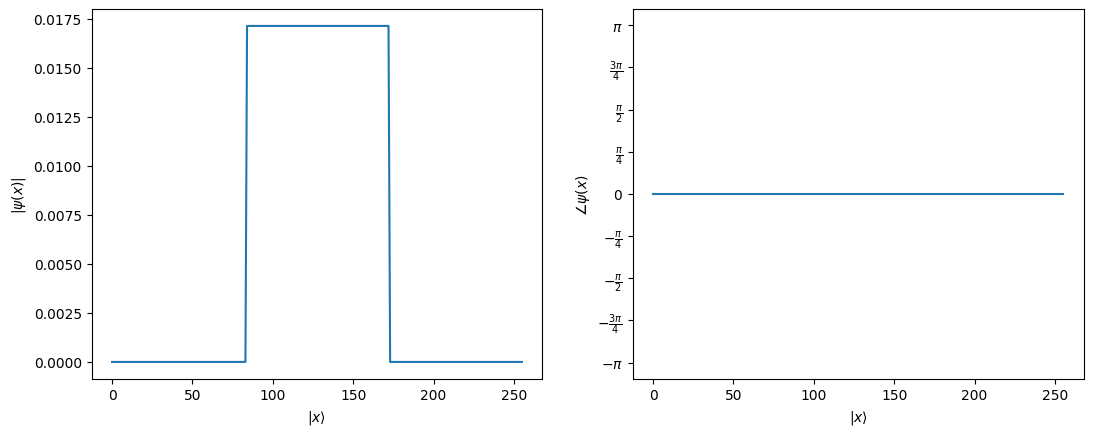

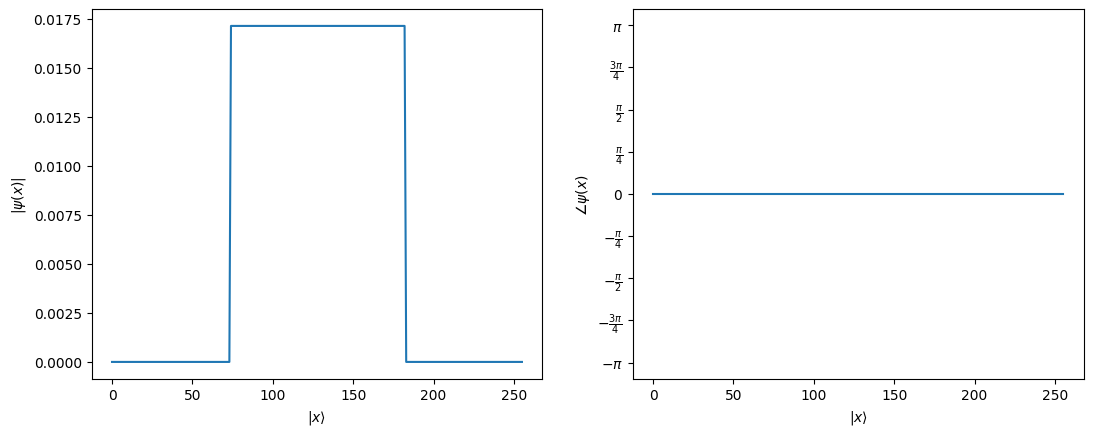

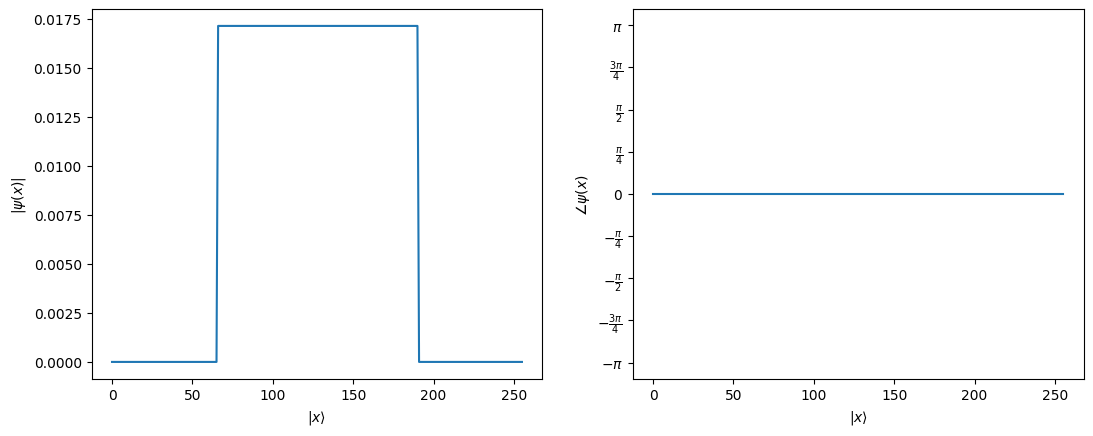

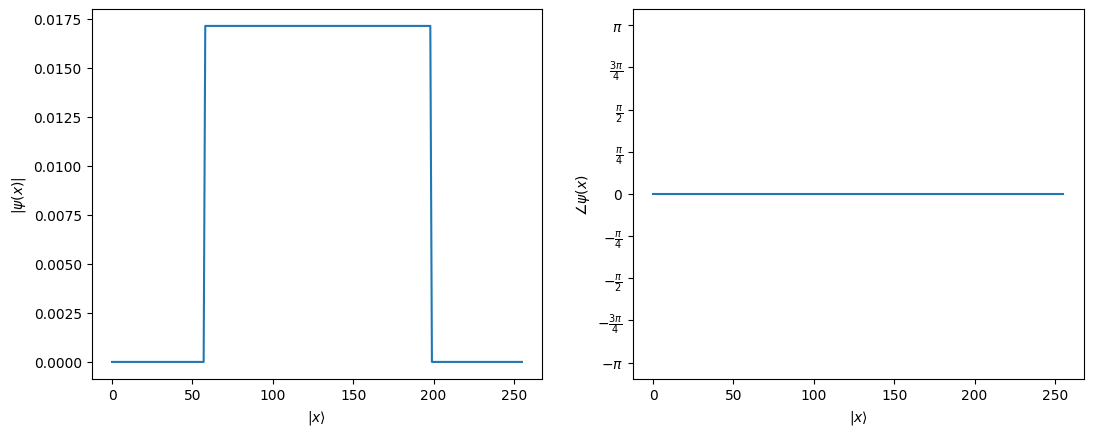

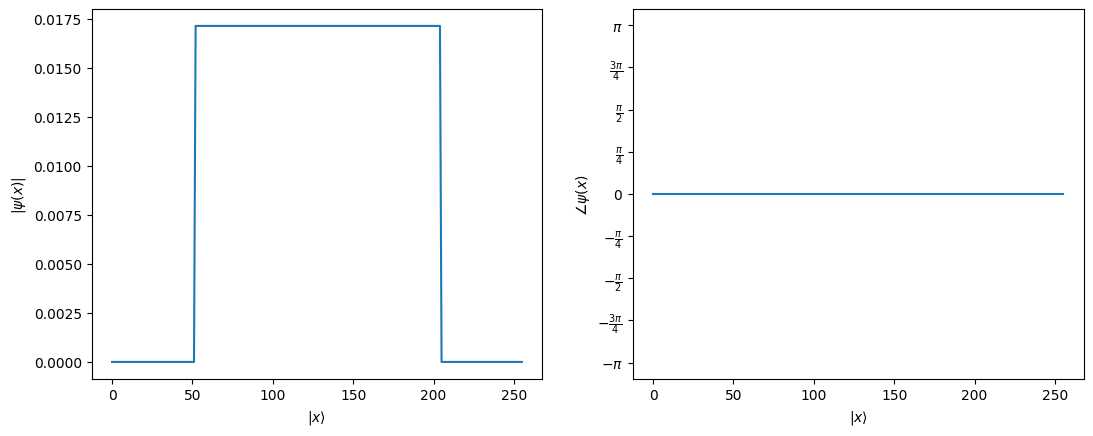

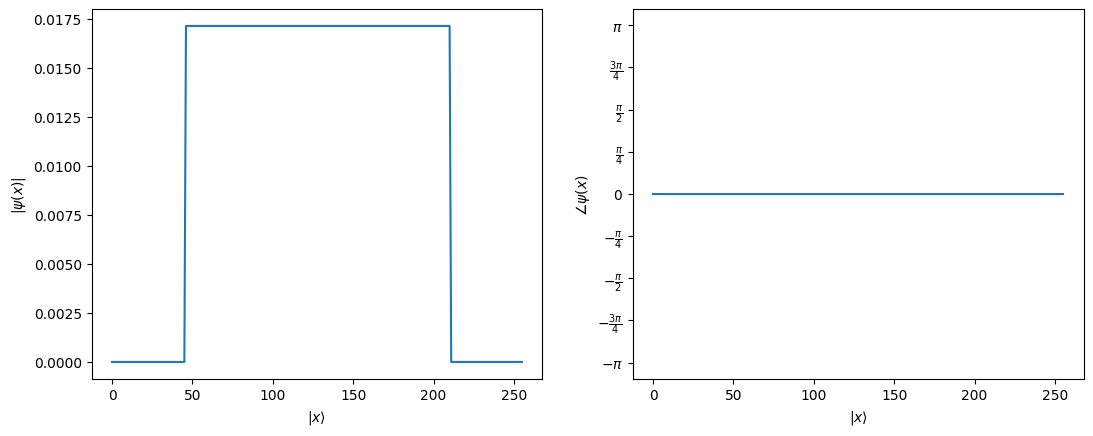

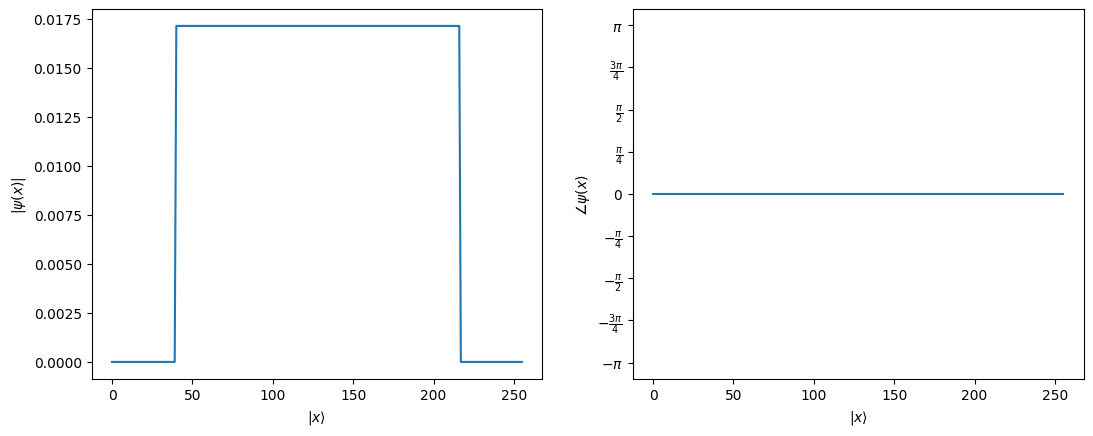

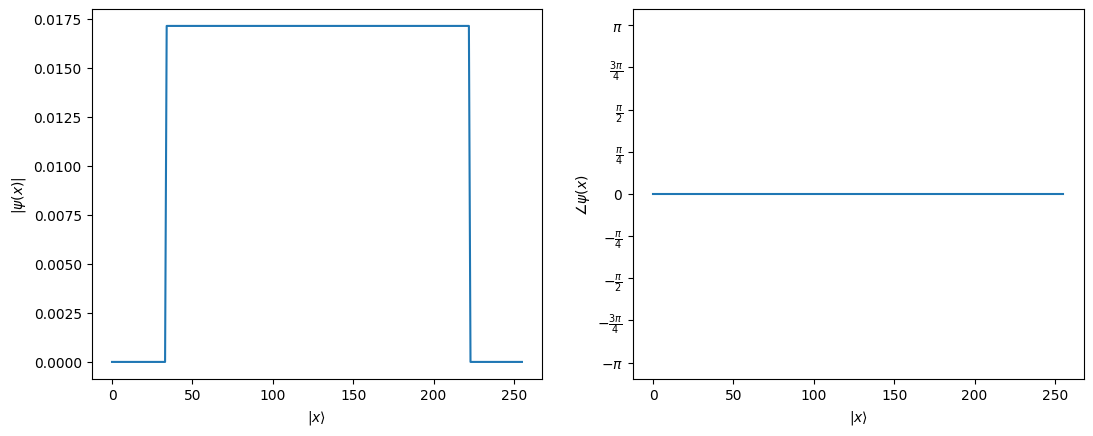

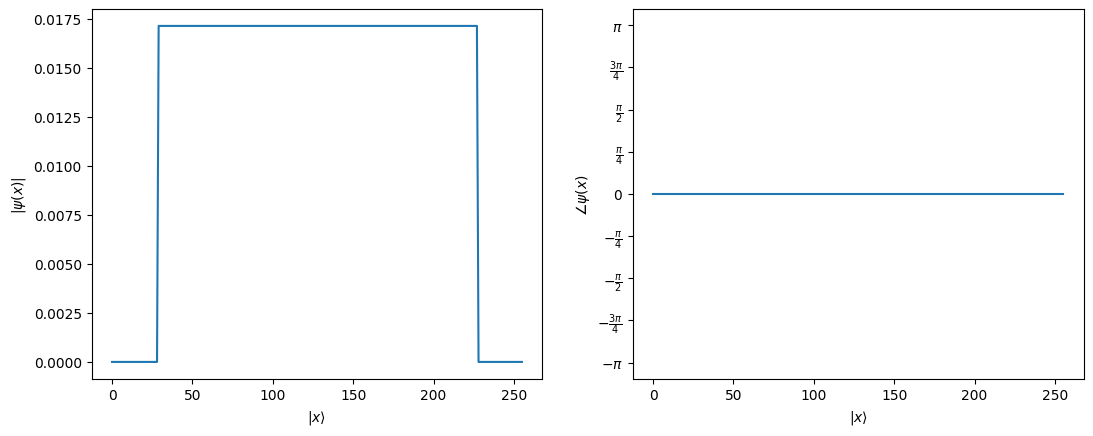

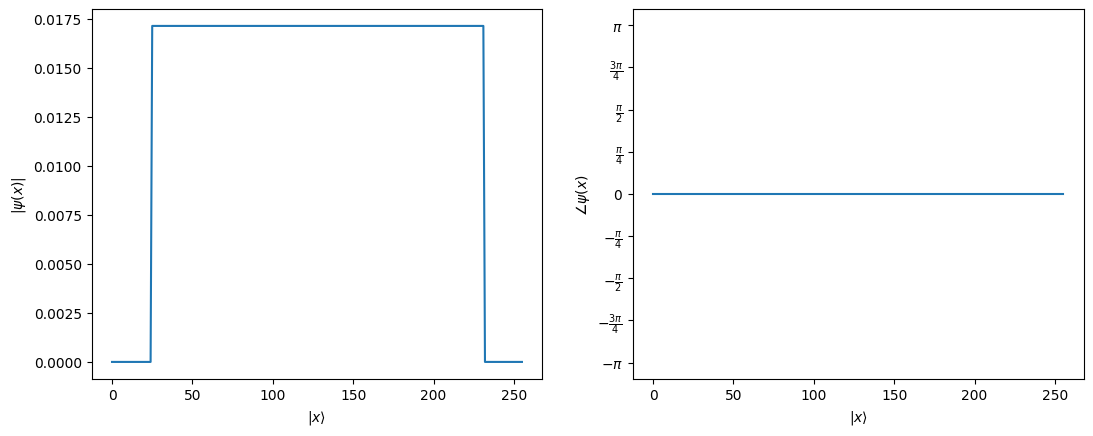

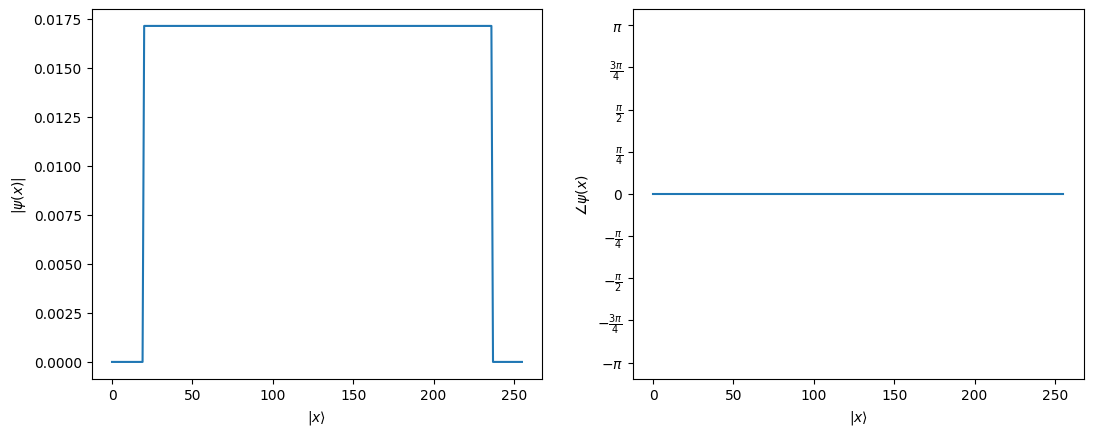

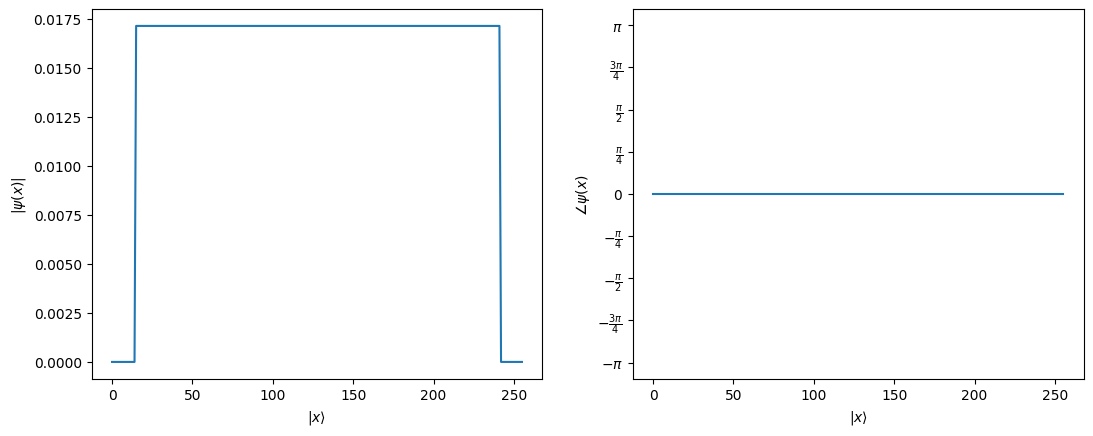

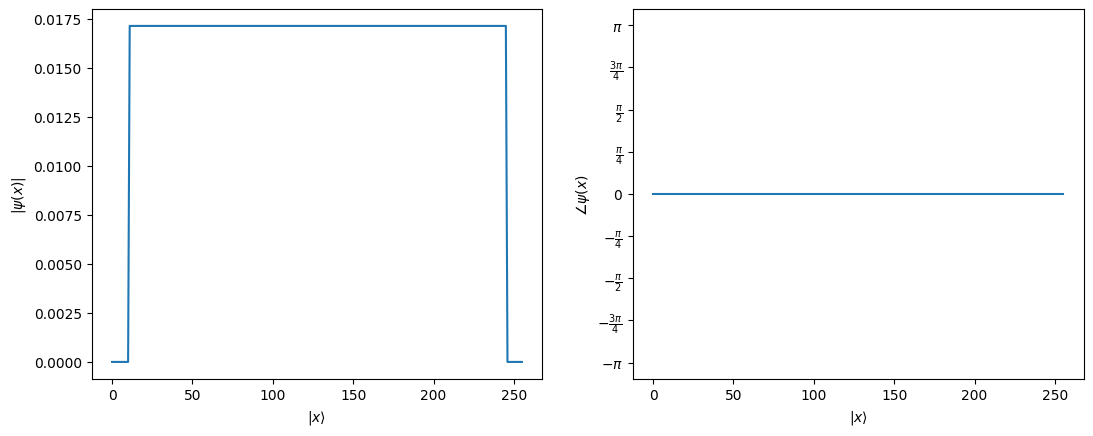

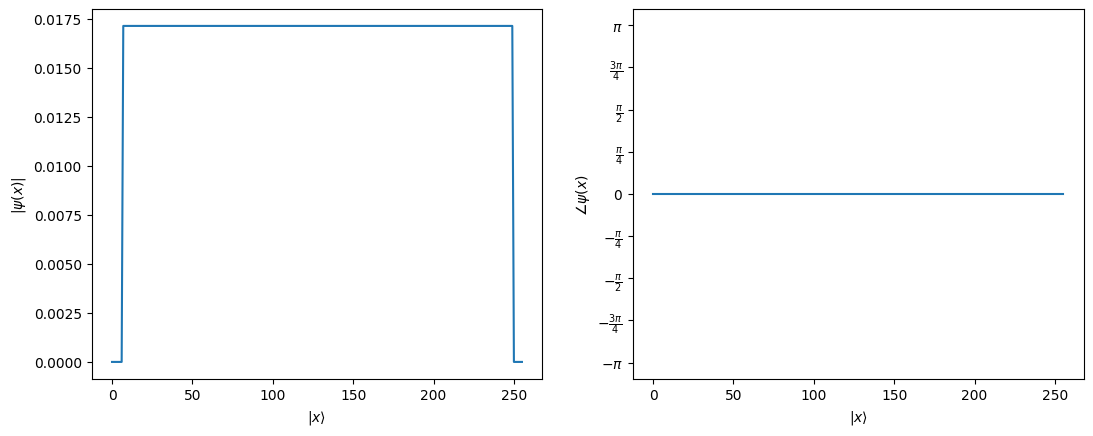

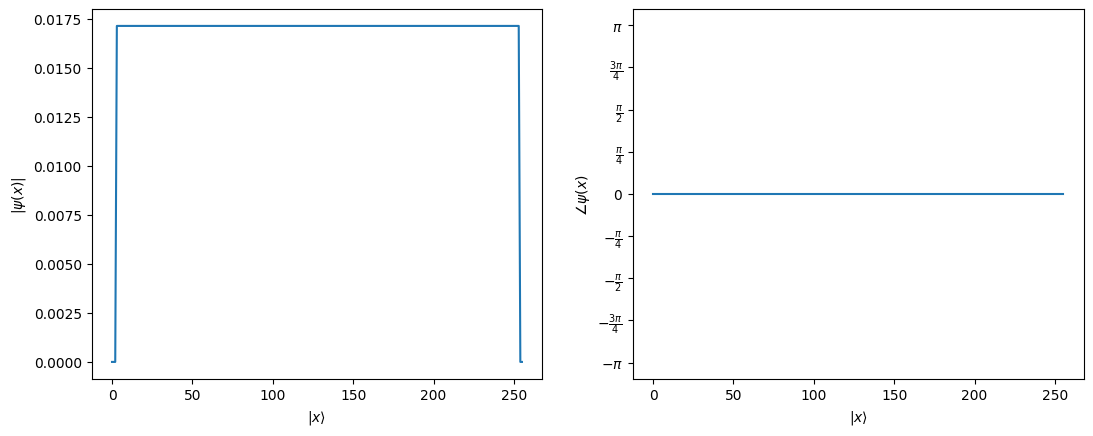

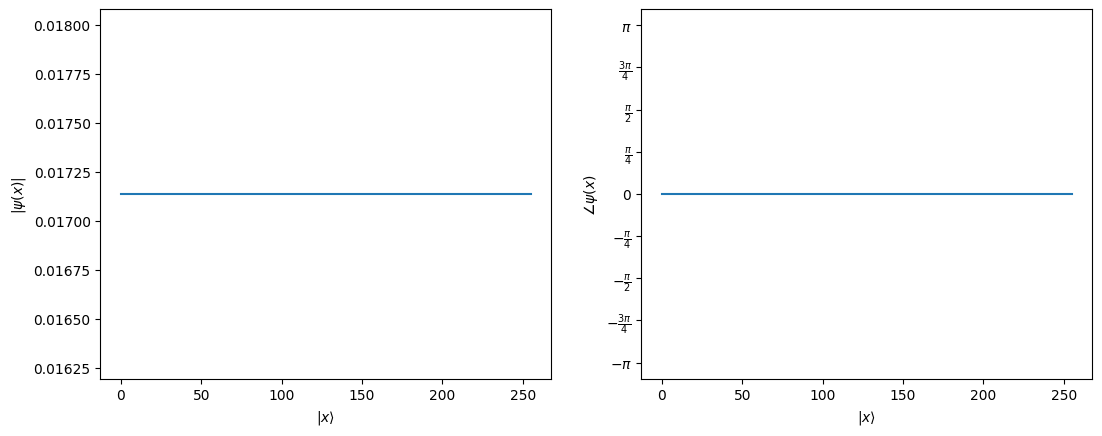

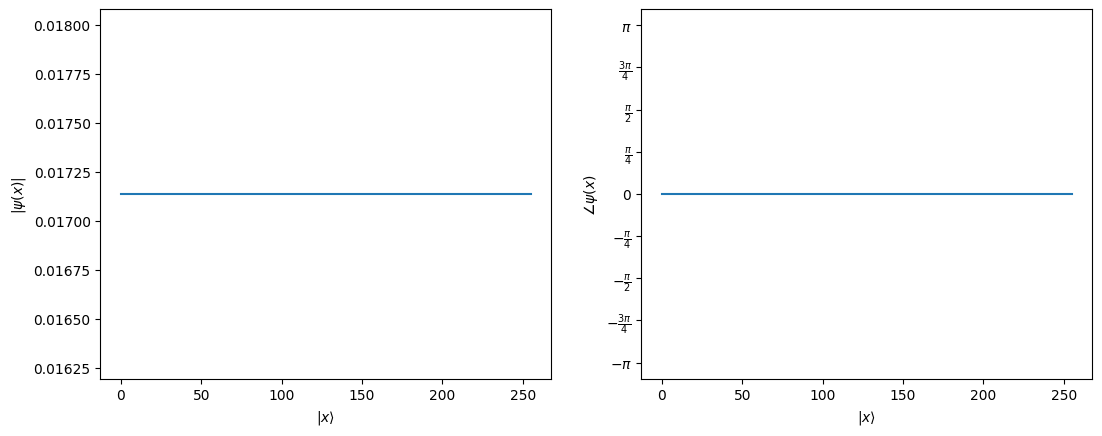

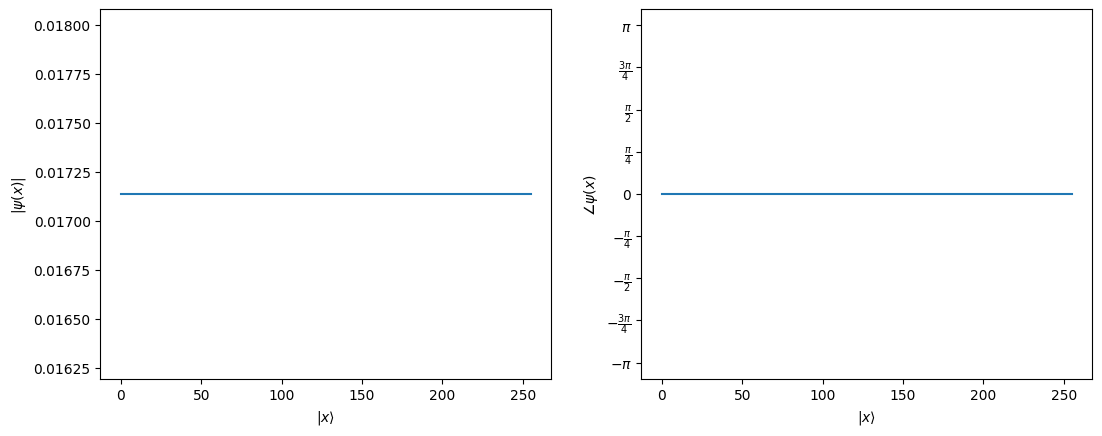

In [54]:
for i, lens_length in enumerate(lens_lengths):
    lens_signal = thin_transparent_plate_signal_generator(
        x_axis=x_axis,
        refractive_index=refractive_index,
        thickness=lens_slice_thickness,
        radius=lens_length,
        wavelength=wavelength,
    )
    plot_wavefunction(lens_signal.data, normalize=False)

In [55]:
psi_reg = QuantumRegister(num_qubits, name=r"\psi")
phi_reg = QuantumRegister(num_qubits, name=r"\phi")
success_flag = ClassicalRegister(num_qubits, name="success_flag")
circuit = QuantumCircuit(psi_reg, phi_reg, success_flag)
# circuit = QuantumCircuit(psi_reg)

psi_flat = Statevector.from_label("+" * num_qubits)

circuit.initialize(psi.data.tolist() / np.linalg.norm(psi.data), psi_reg)
# circuit.initialize(psi_flat, psi_reg)

circuit.save_statevector(label=f"step_{0}")  # type: ignore

### Lens
for i, lens_length in enumerate(lens_lengths):
    print(f"Doing lens slice {i + 1}/{lens_slices}")

    lens_signal = thin_transparent_plate_signal_generator(
        x_axis=x_axis,
        refractive_index=refractive_index,
        thickness=lens_slice_thickness,
        radius=lens_length,
        wavelength=wavelength,
    )
    sample_based_lens_signal = (
        ArbitrarySignalForSampleBasedProtocol.from_generic_signal(lens_signal)
    )
    print(np.max(np.abs(sample_based_lens_signal.data)))
    print(np.sum(np.abs(sample_based_lens_signal.data) ** 2))
    # continue
    lens = QuadraticSignalSampleBasedPhasePropagator(
        signal=sample_based_lens_signal, max_delta=max_delta
    )
    print(f"had {lens.num_of_cycles} cycles")

    circuit.compose(
        lens,
        circuit.qubits,
        circuit.clbits,
        inplace=True,
    )

    propagator_signal = free_space_signal_generator(
        k_axis=k_axis,
        delta_t=lens_slice_thickness / c,
        wavelength=wavelength,
        c=constants.c,
    )
    propagator = MomentumDomainEvolutionQuadratic(quadratic_signal=propagator_signal)

    circuit.compose(
        propagator,
        psi_reg,
        inplace=True,
    )
    circuit.save_statevector(label=f"step_lens_{i}")  # type: ignore


for i in range(num_of_steps_after_lens):
    print(f"Doing free space step {i + 1}/{num_of_steps_after_lens}")

    propagator_signal = free_space_signal_generator(
        k_axis=k_axis,
        delta_t=step_size_after_lens / c,
        wavelength=wavelength,
        c=constants.c,
    )
    propagator = MomentumDomainEvolutionQuadratic(quadratic_signal=propagator_signal)

    circuit.compose(
        propagator,
        psi_reg,
        inplace=True,
    )
    circuit.save_statevector(label=f"step_after_lens_{i + 1}")  # type: ignore

Doing lens slice 1/20
0.017135959928671597
0.0002936411226770387
Using ideal state initializer.
had 1 cycles
Doing lens slice 2/20
0.017135959928671597
0.01849939072865344
Using ideal state initializer.
had 11 cycles
Doing lens slice 3/20
0.017135959928671597
0.026134059918256444
Using ideal state initializer.
had 16 cycles
Doing lens slice 4/20
0.017135959928671597
0.032006882371797225
Using ideal state initializer.
had 19 cycles
Doing lens slice 5/20
0.017135959928671597
0.03670514033462984
Using ideal state initializer.
had 22 cycles
Doing lens slice 6/20
0.017135959928671597
0.04140339829746246
Using ideal state initializer.
had 25 cycles
Doing lens slice 7/20
0.017135959928671597
0.04492709176958692
Using ideal state initializer.
had 27 cycles
Doing lens slice 8/20
0.017135959928671597
0.048450785241711376
Using ideal state initializer.
had 29 cycles
Doing lens slice 9/20
0.017135959928671597
0.05197447871383584
Using ideal state initializer.
had 31 cycles
Doing lens slice 10/20
0

In [56]:
simulator = generate_aer_simulator()
transpiled_circuit = transpile(circuit, simulator)
job = simulator.run(transpiled_circuit, shots=1)
result = job.result()

In [57]:
counts = result.get_counts().int_outcomes()
assert counts[0] == 1

In [58]:
# def process_statevector(statevector):
#     return statevector
def process_statevector(statevector):
    """Process the statevector to extract position probabilities."""
    n = statevector.num_qubits
    rho = partial_trace(statevector, np.arange(int(n // 2), n).tolist())
    reduced_state = rho.to_statevector()

    return reduced_state


initial_statevector = process_statevector(result.data()[f"step_{0}"])

lens_statevectors = [
    process_statevector(result.data()[f"step_lens_{i}"]) for i in range(lens_slices)
]
after_lens_statevectors = [
    process_statevector(result.data()[f"step_after_lens_{i + 1}"])
    for i in range(num_of_steps_after_lens)
]

Plotting initial state


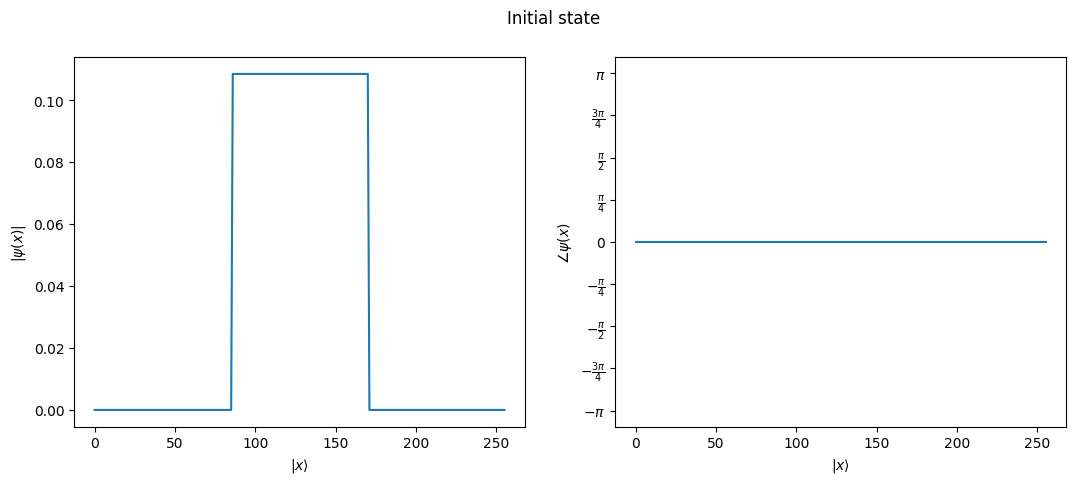

Plotting lens slice 1/20


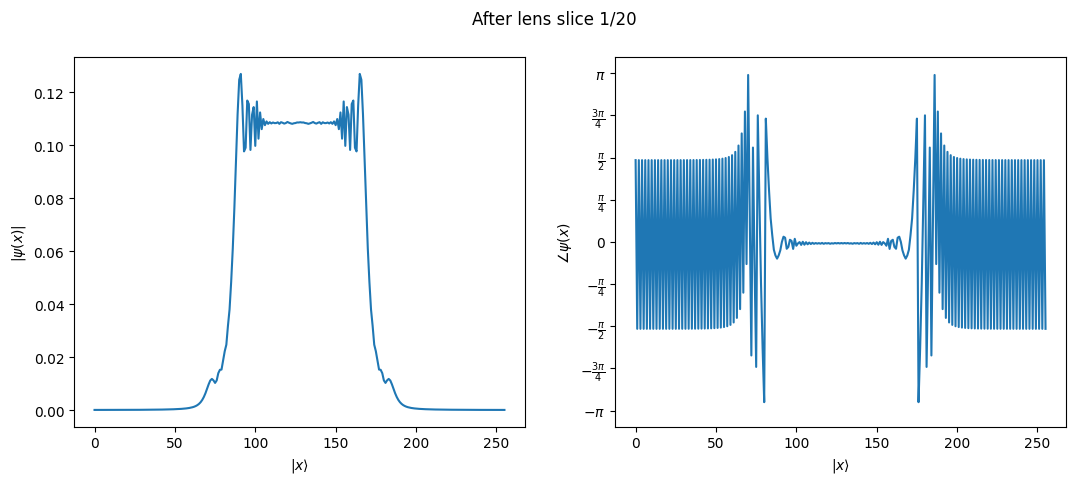

Plotting lens slice 2/20


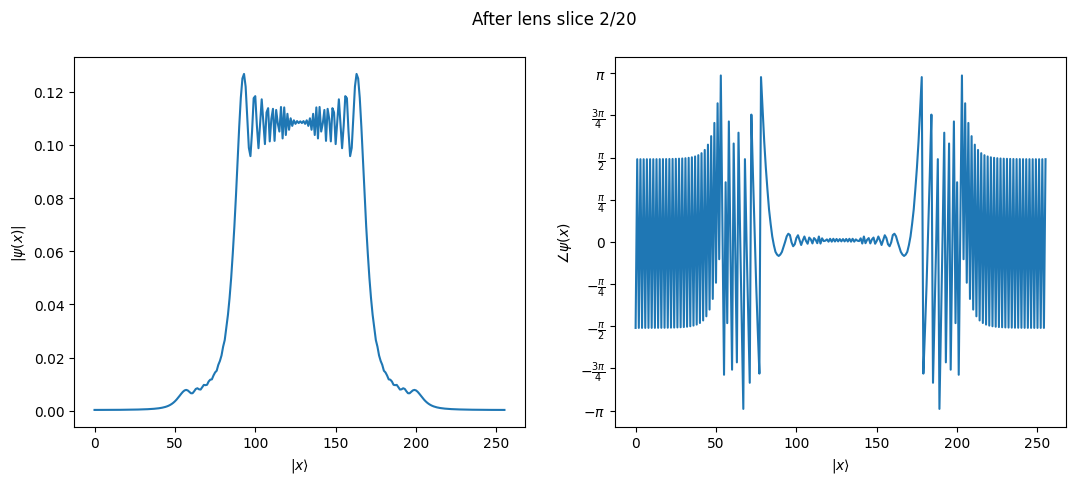

Plotting lens slice 3/20


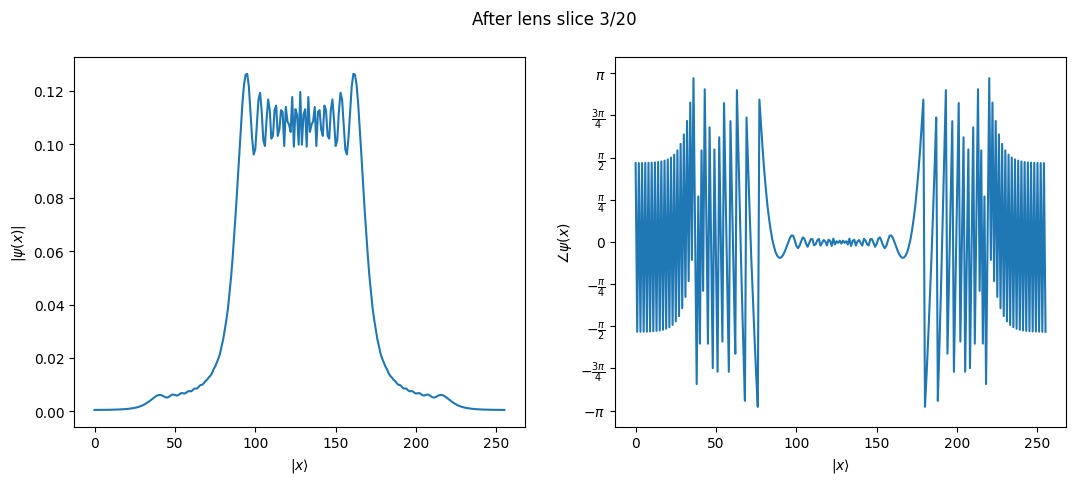

Plotting lens slice 4/20


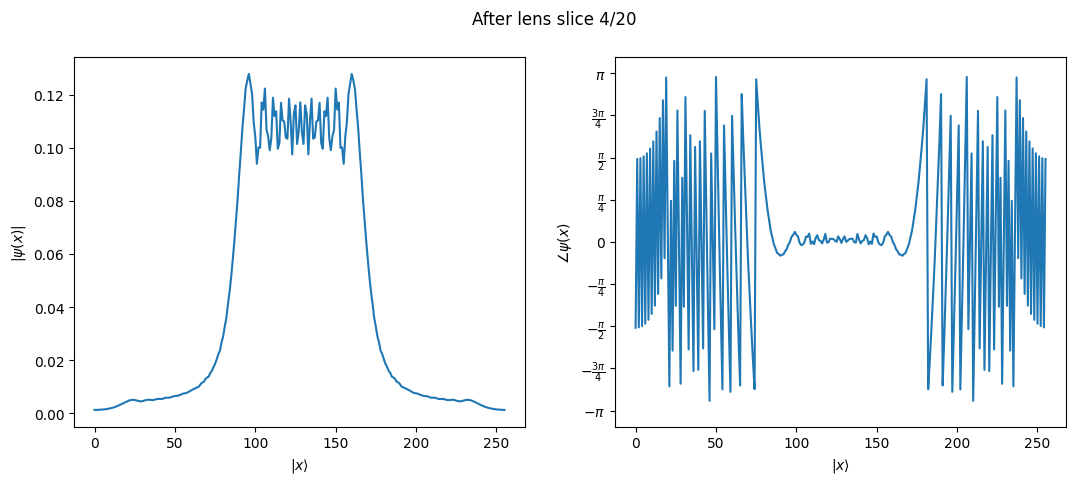

Plotting lens slice 5/20


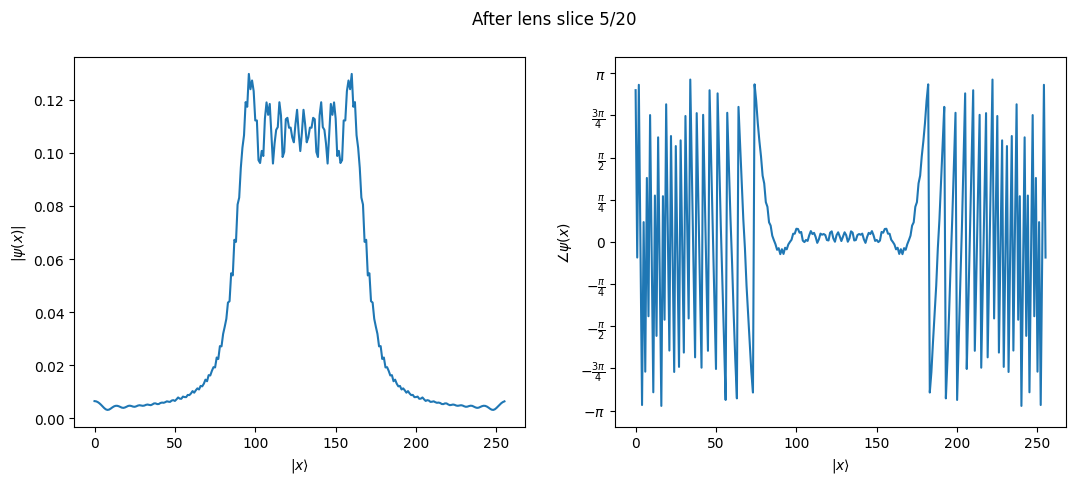

Plotting lens slice 6/20


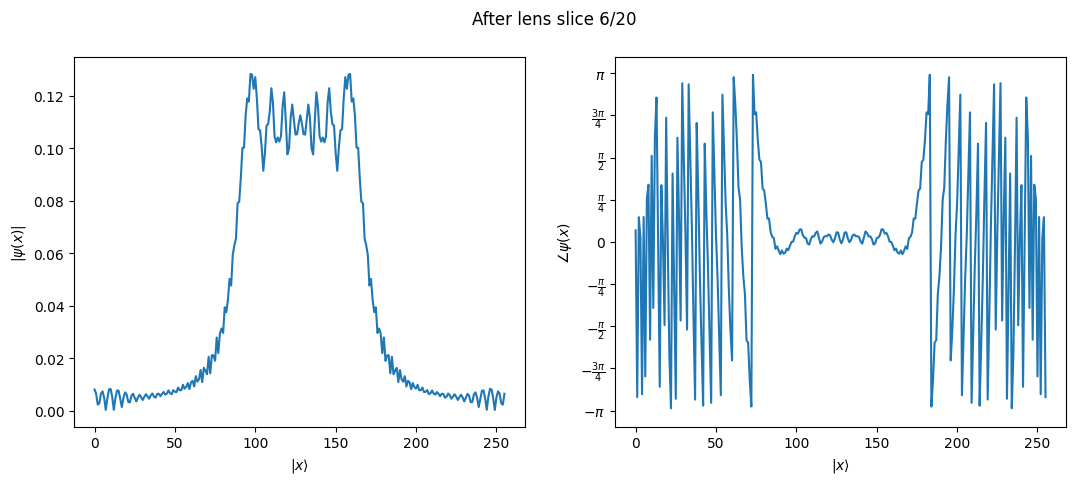

Plotting lens slice 7/20


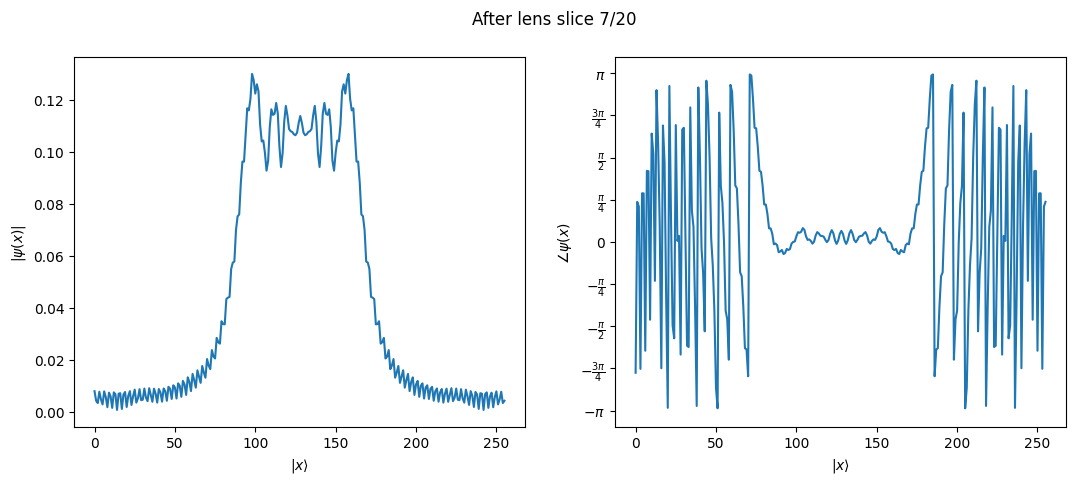

Plotting lens slice 8/20


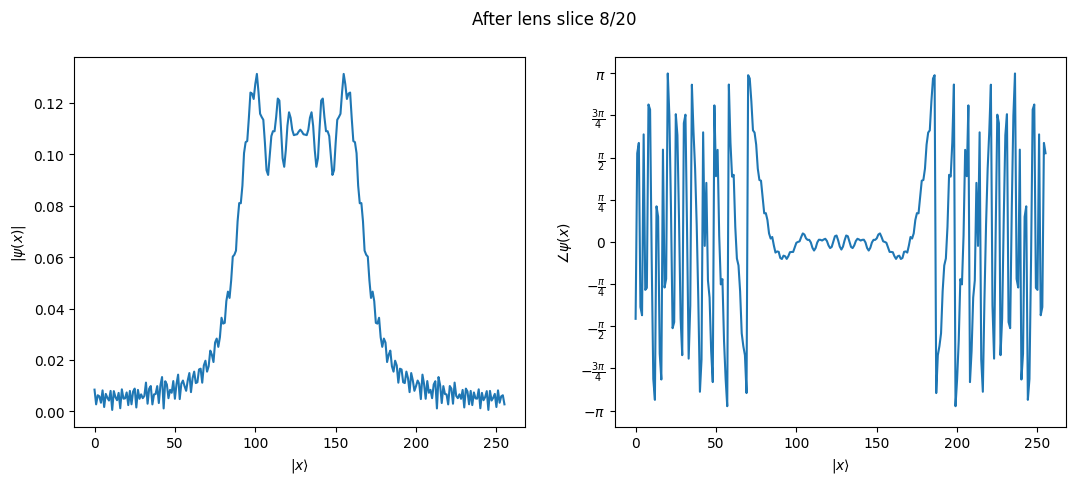

Plotting lens slice 9/20


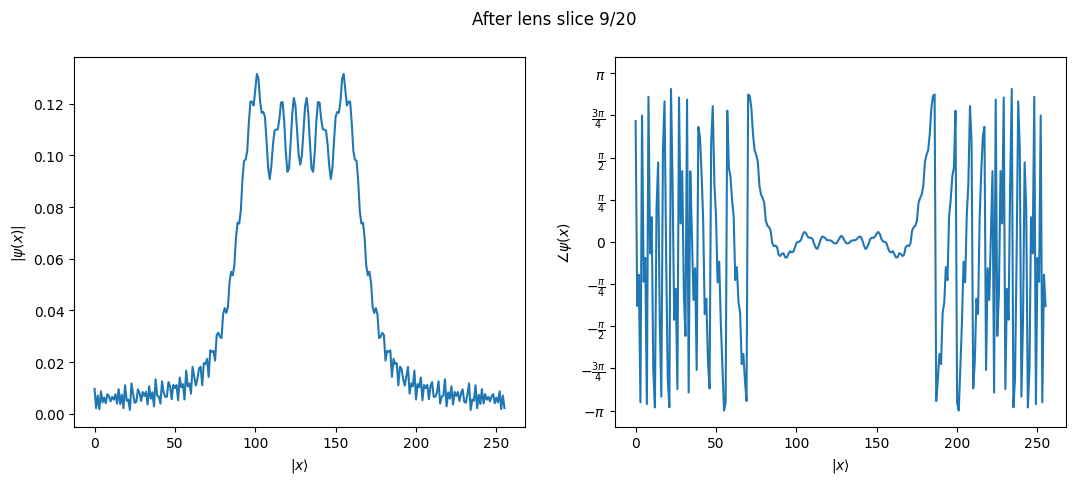

Plotting lens slice 10/20


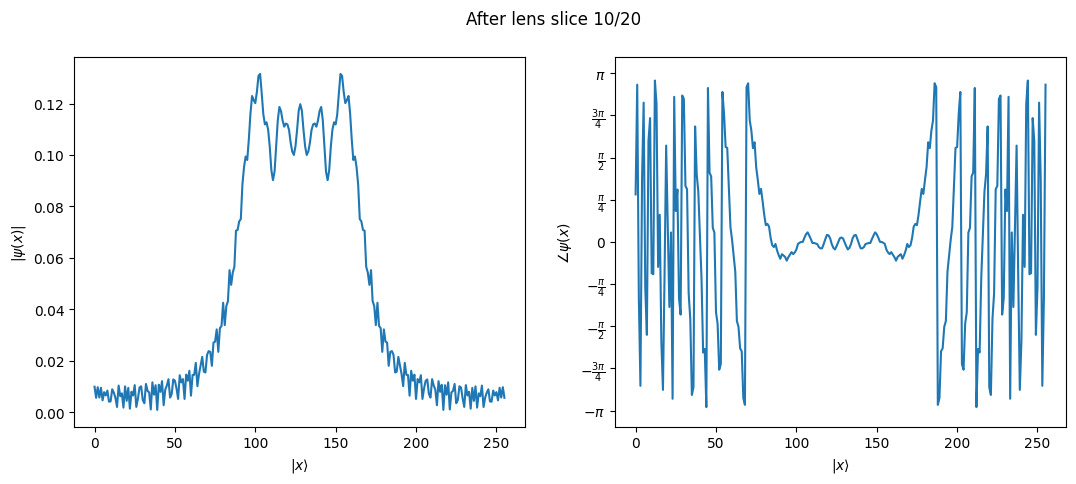

Plotting lens slice 11/20


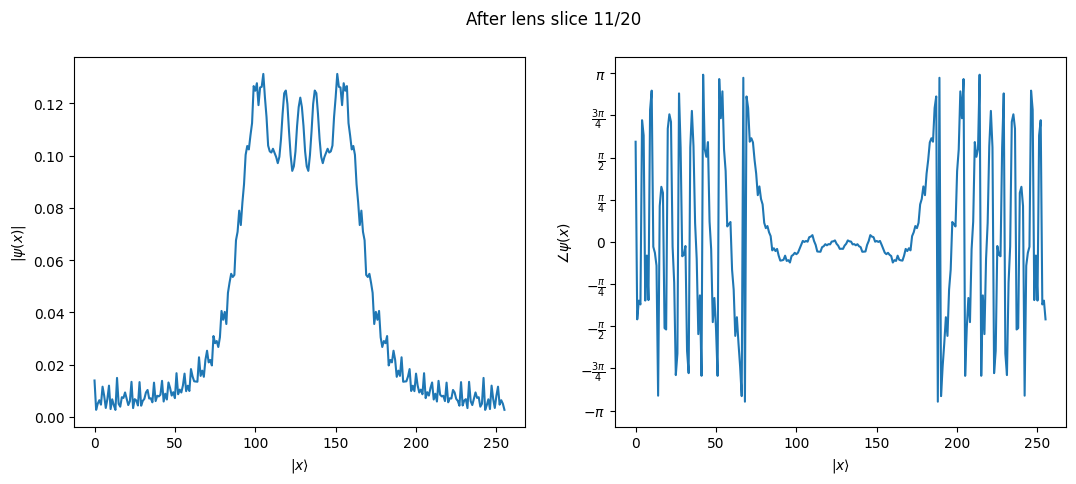

Plotting lens slice 12/20


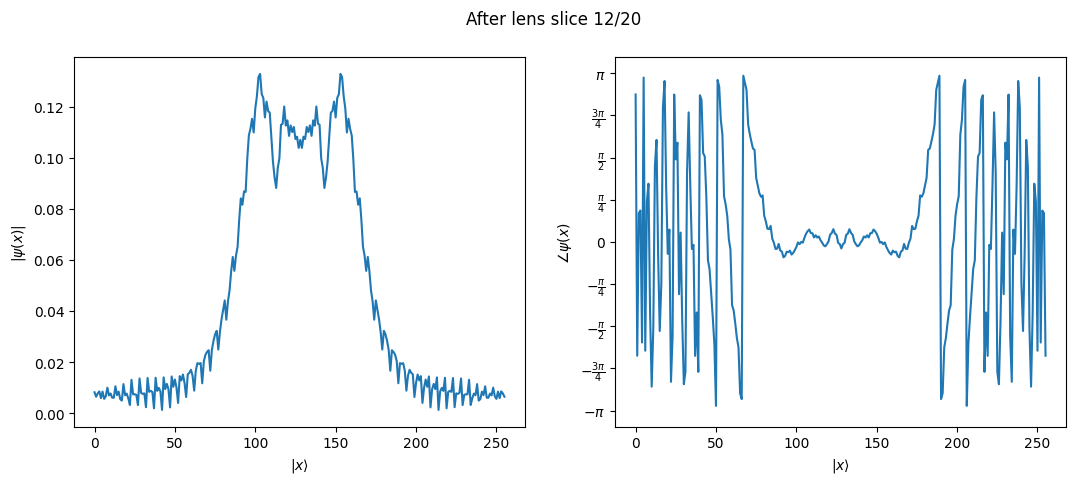

Plotting lens slice 13/20


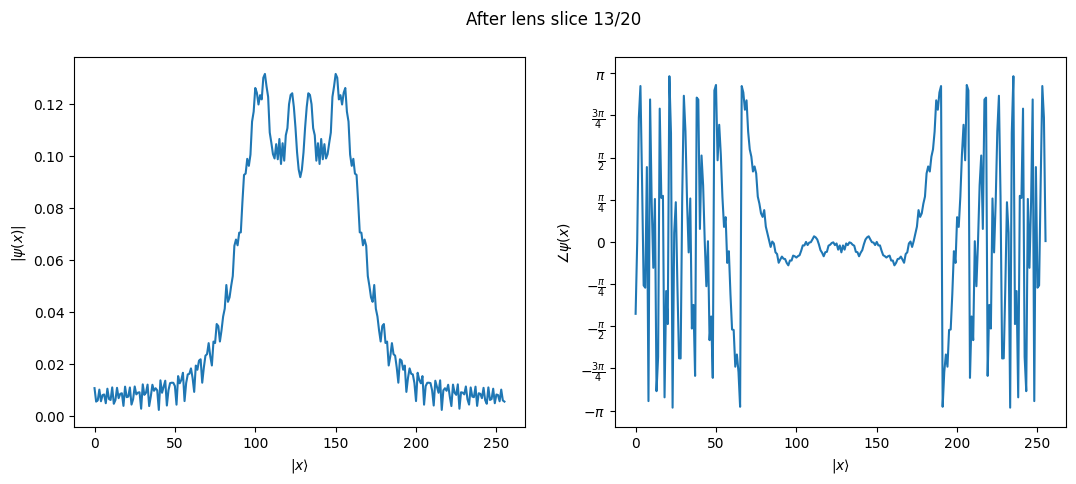

Plotting lens slice 14/20


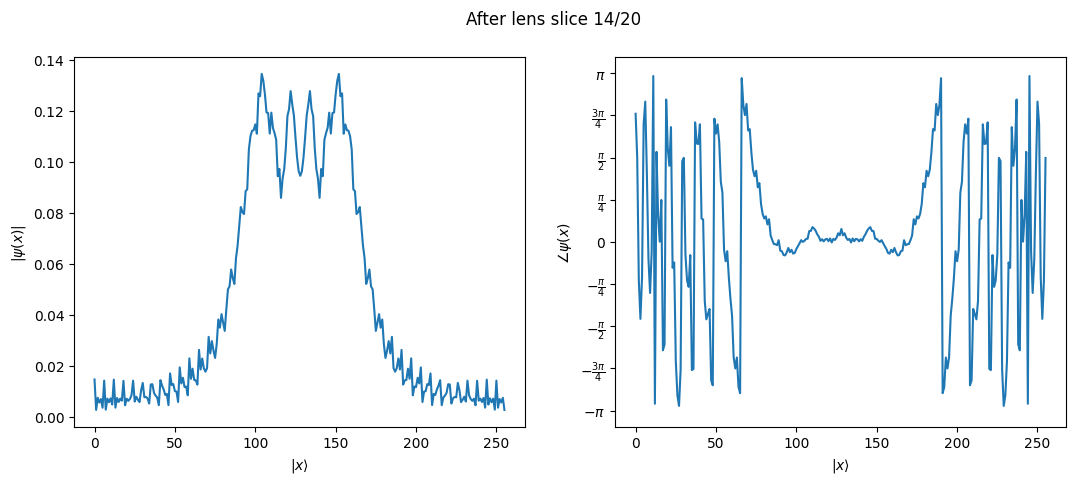

Plotting lens slice 15/20


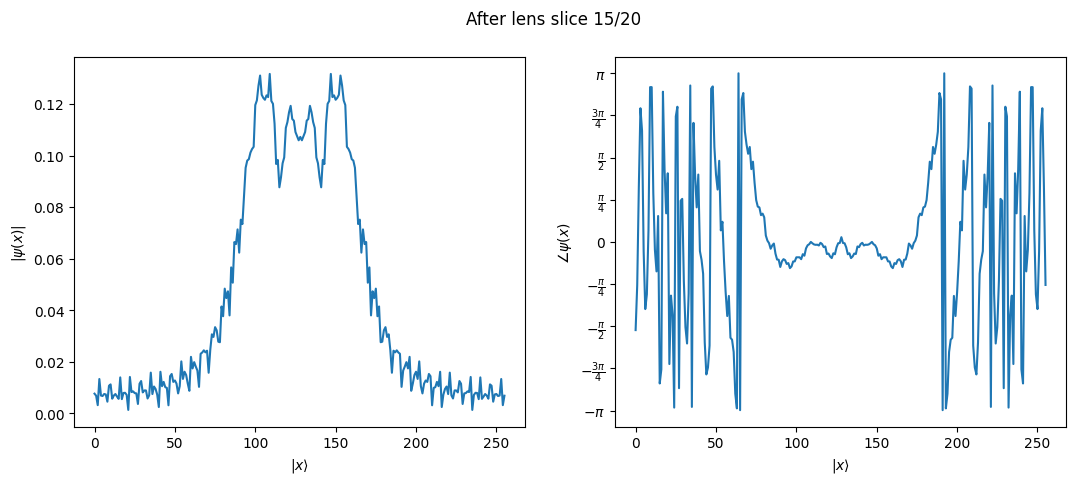

Plotting lens slice 16/20


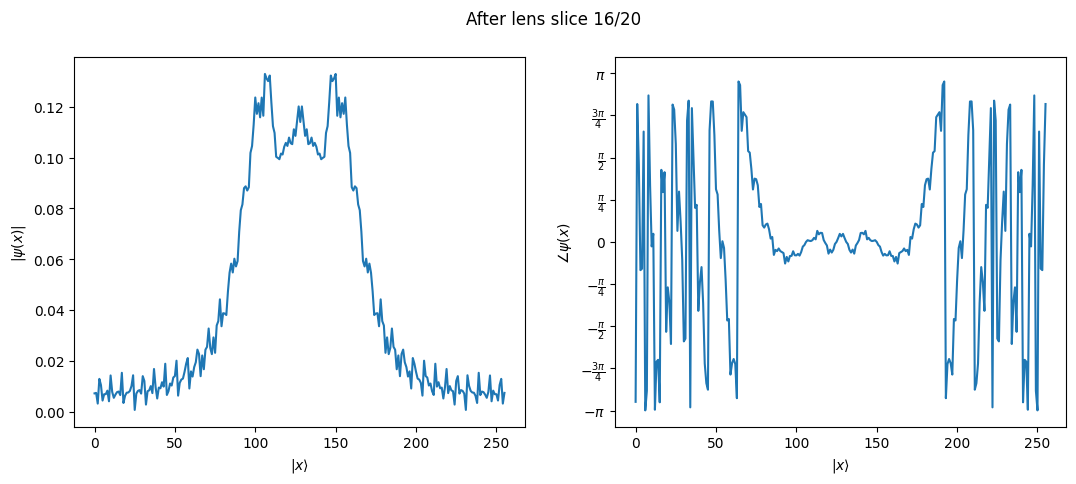

Plotting lens slice 17/20


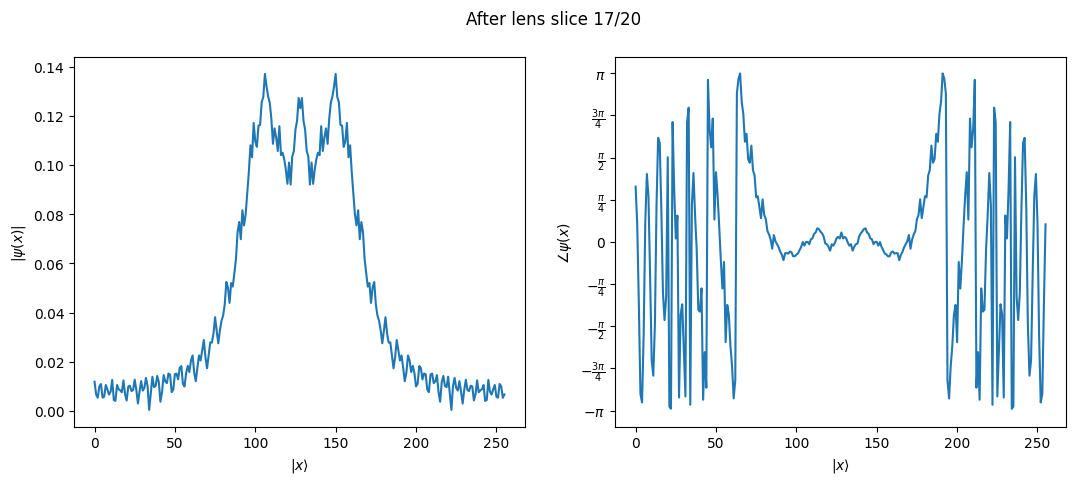

Plotting lens slice 18/20


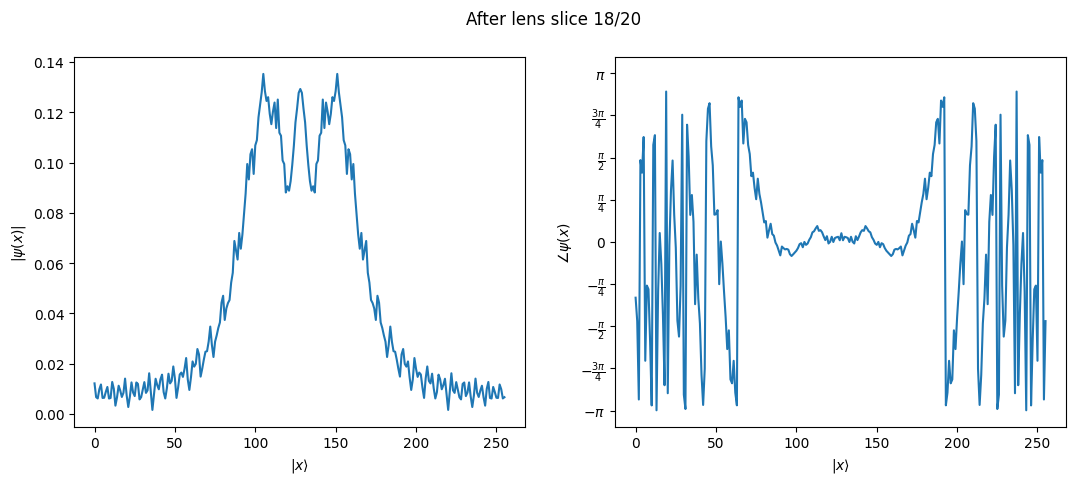

Plotting lens slice 19/20


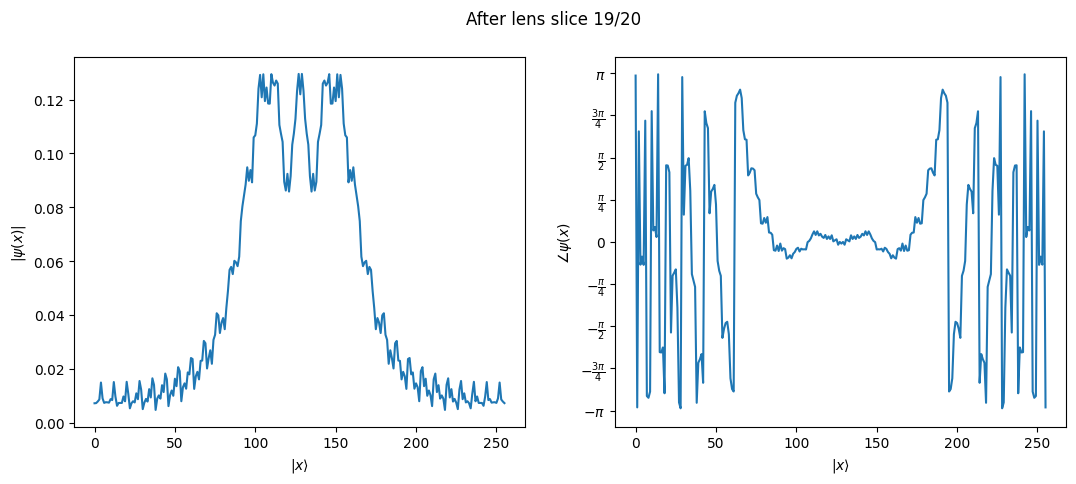

Plotting lens slice 20/20


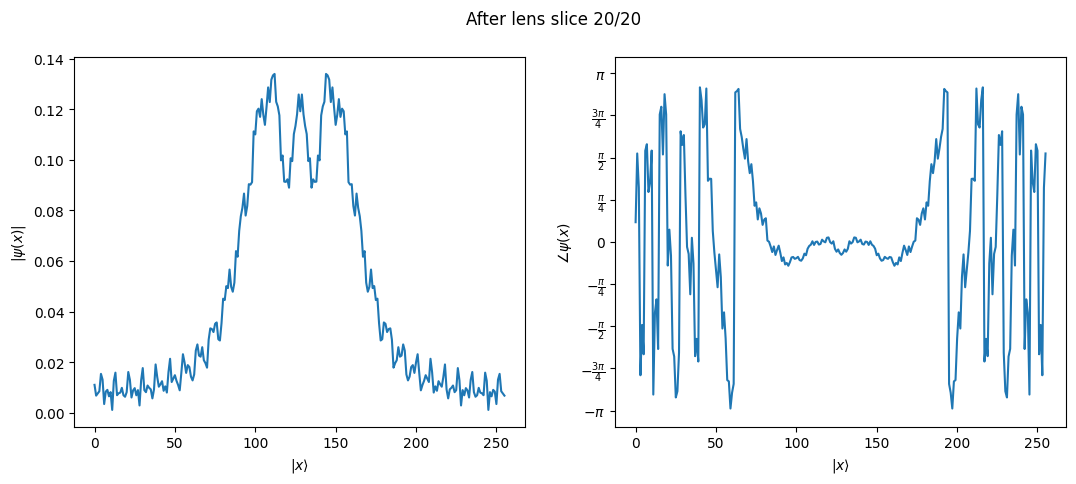

Plotting free space step 1/40


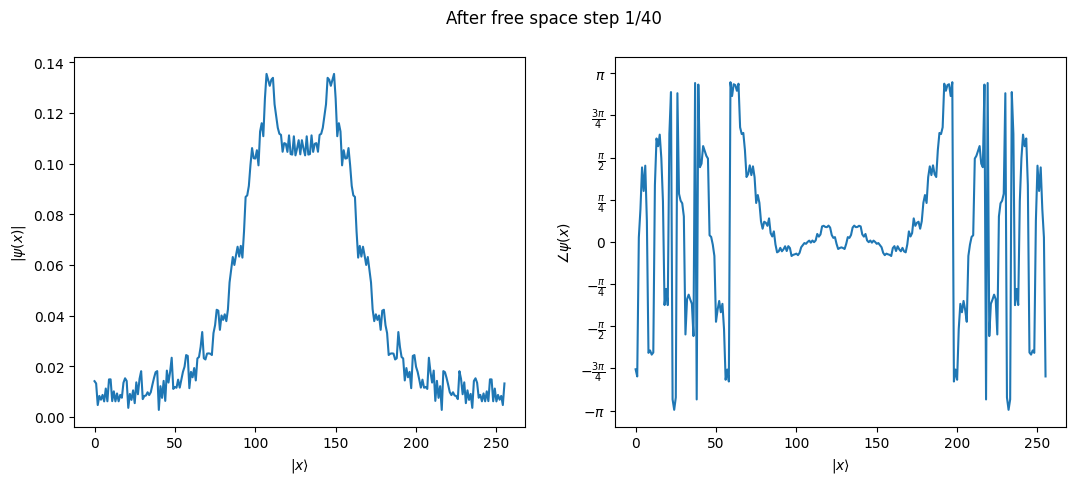

Plotting free space step 2/40


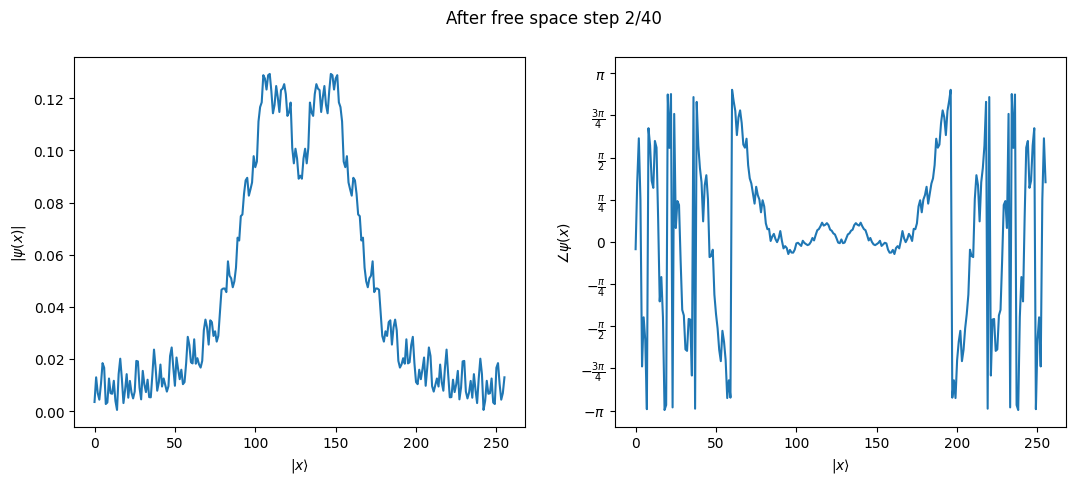

Plotting free space step 3/40


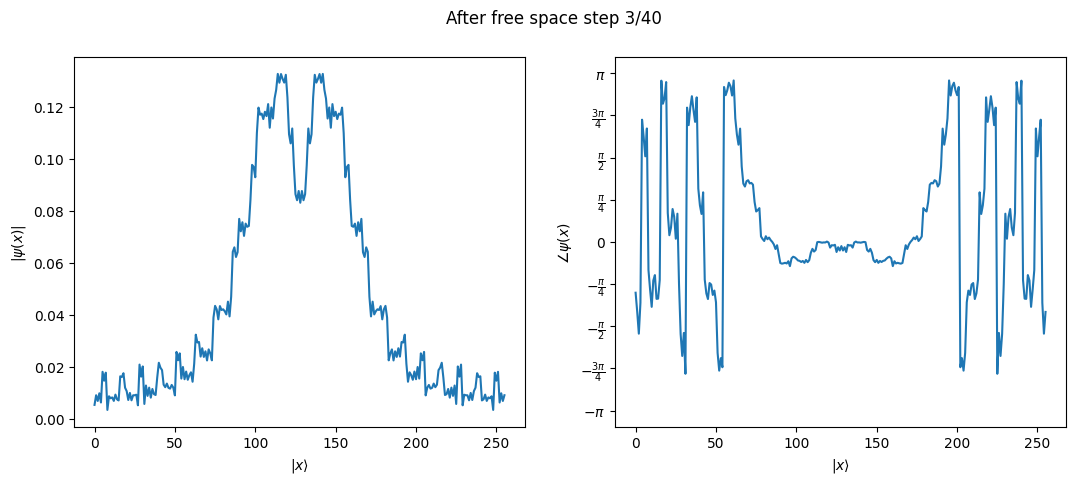

Plotting free space step 4/40


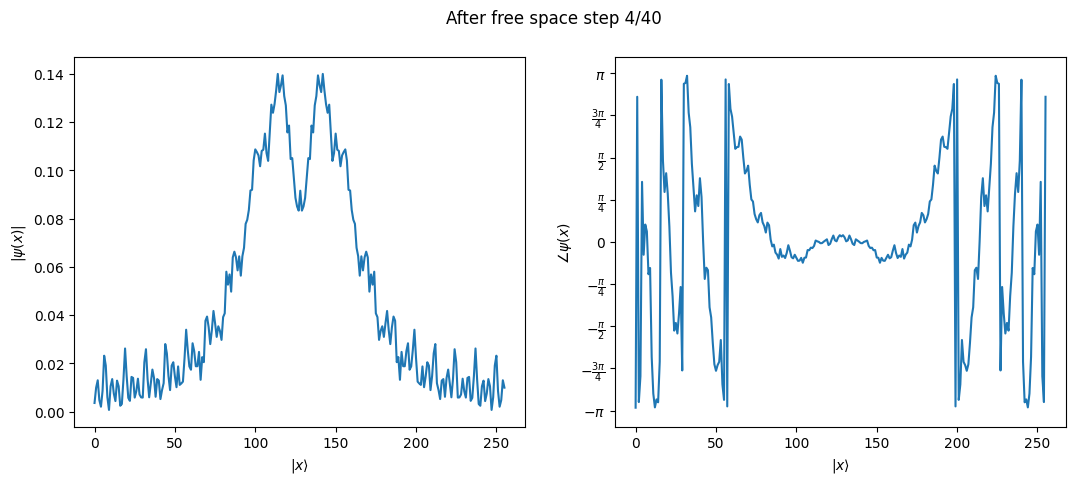

Plotting free space step 5/40


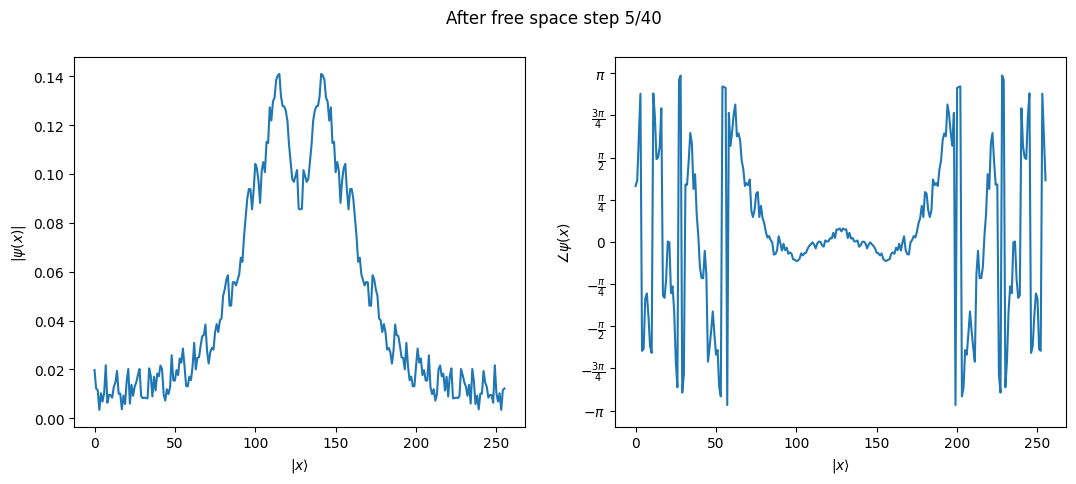

Plotting free space step 6/40


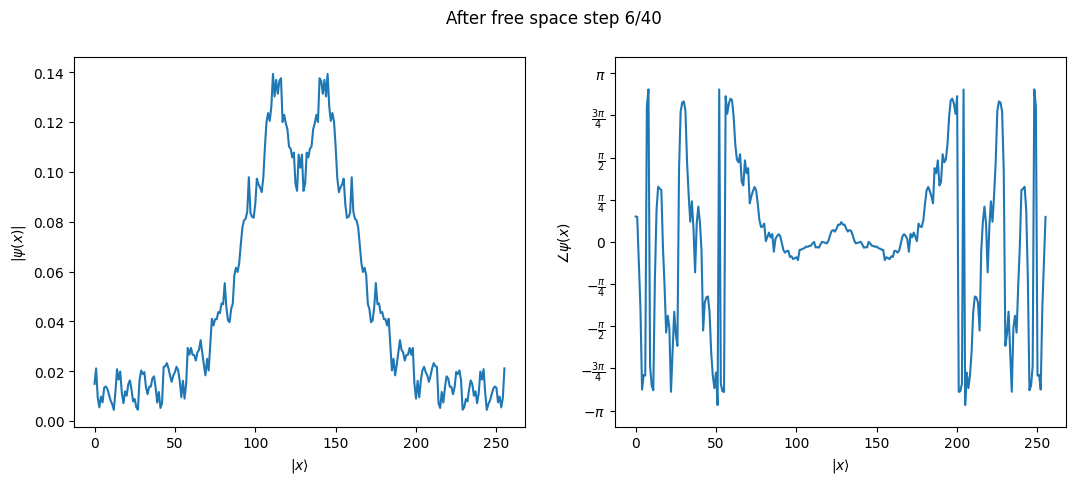

Plotting free space step 7/40


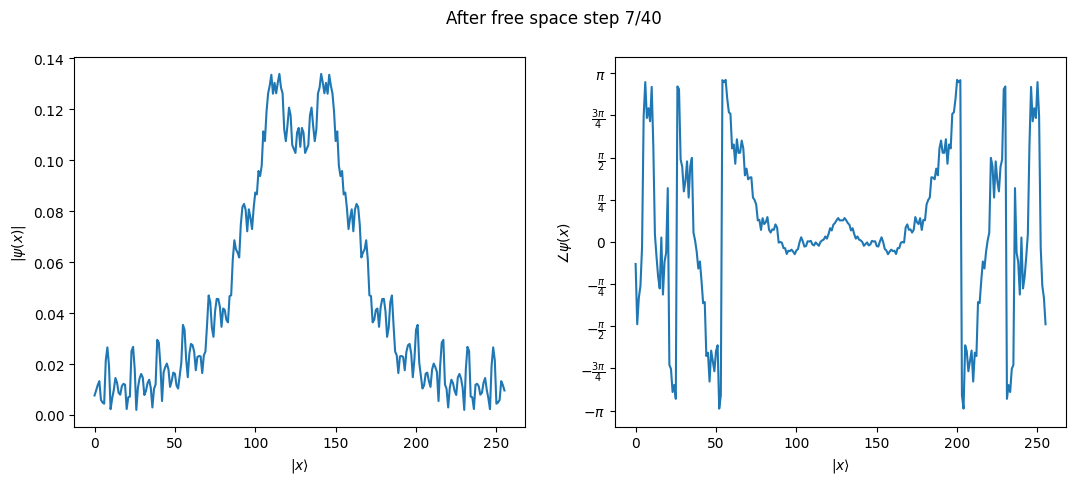

Plotting free space step 8/40


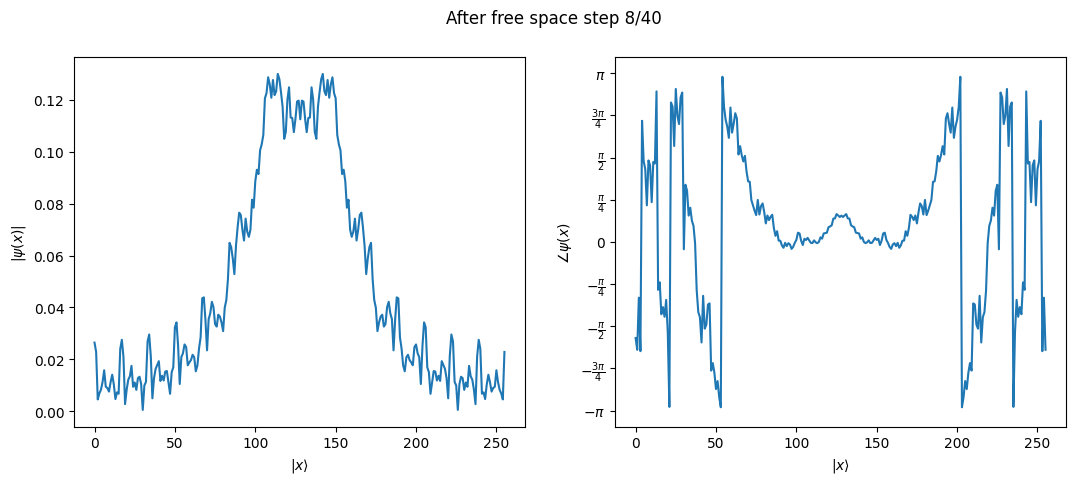

Plotting free space step 9/40


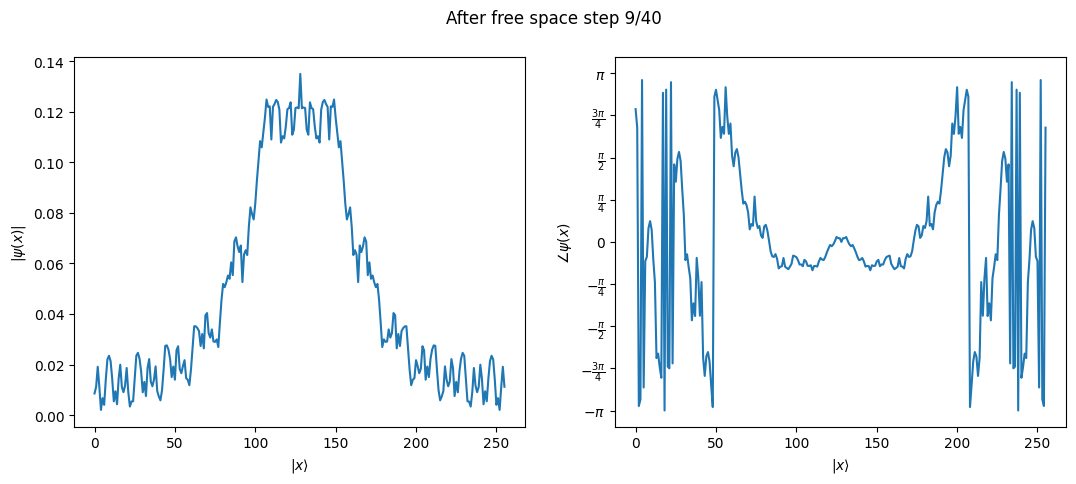

Plotting free space step 10/40


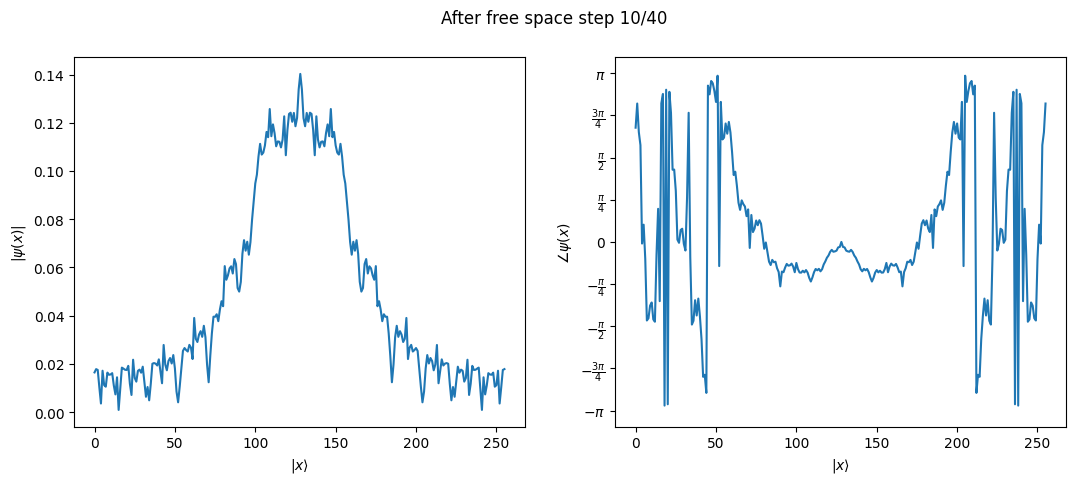

Plotting free space step 11/40


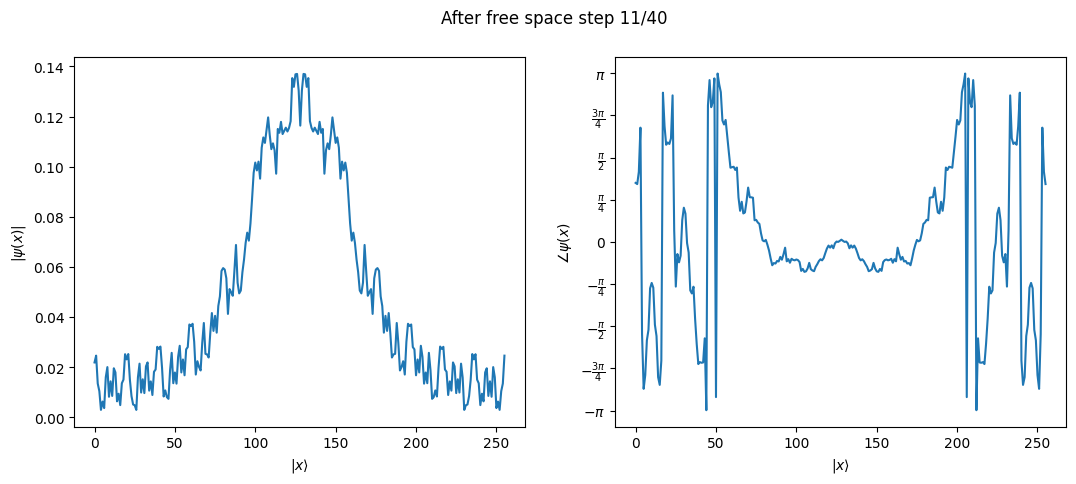

Plotting free space step 12/40


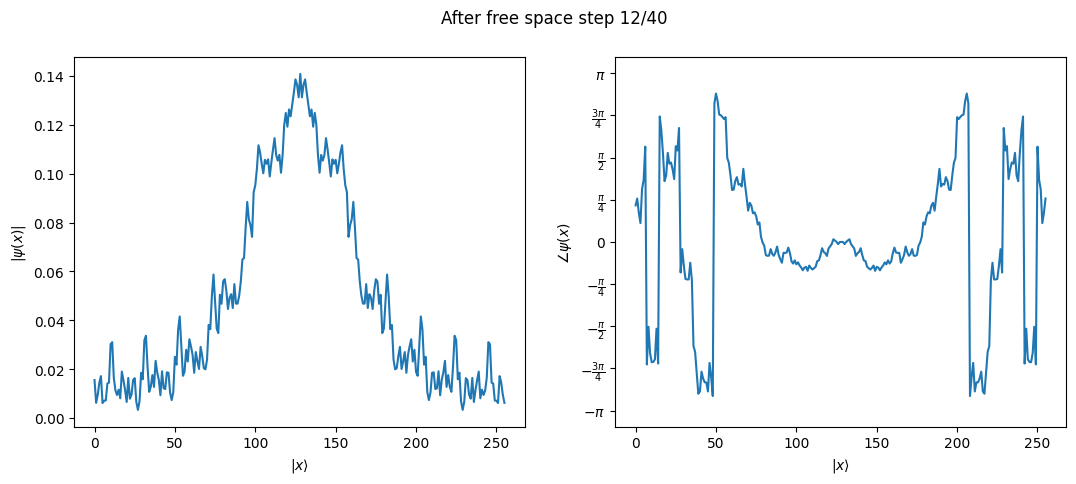

Plotting free space step 13/40


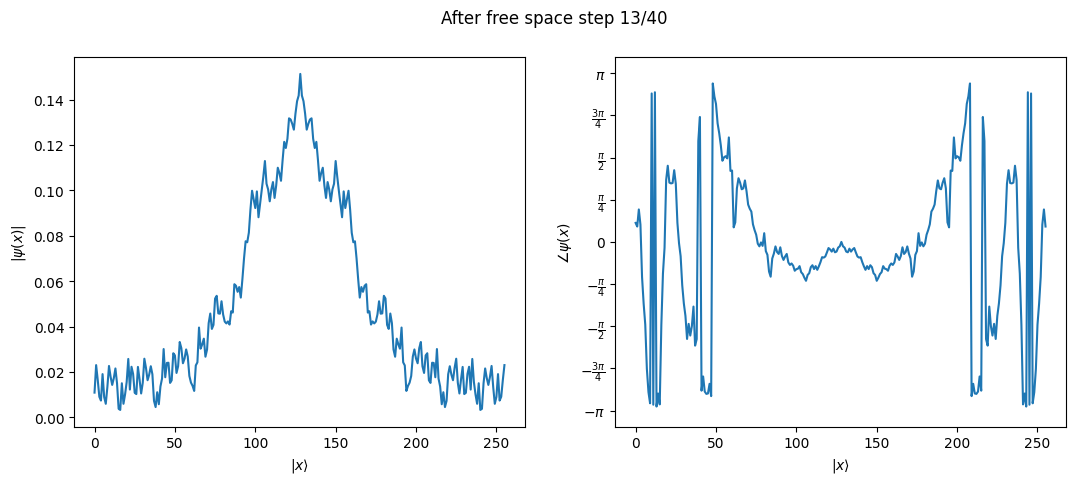

Plotting free space step 14/40


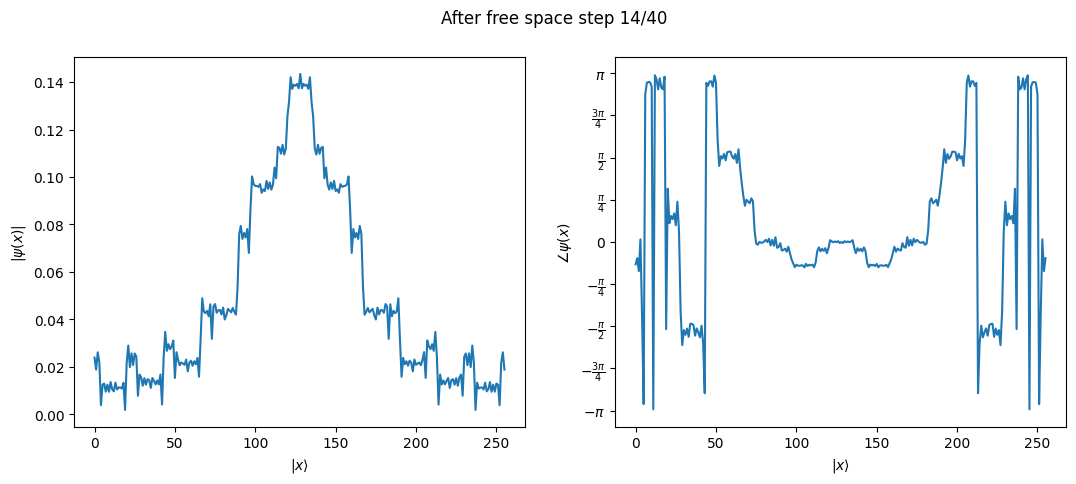

Plotting free space step 15/40


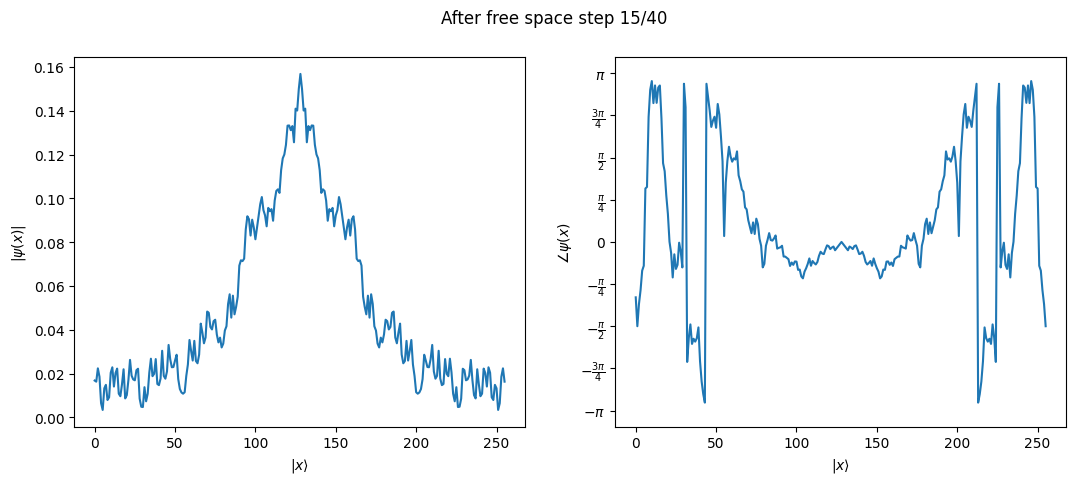

Plotting free space step 16/40


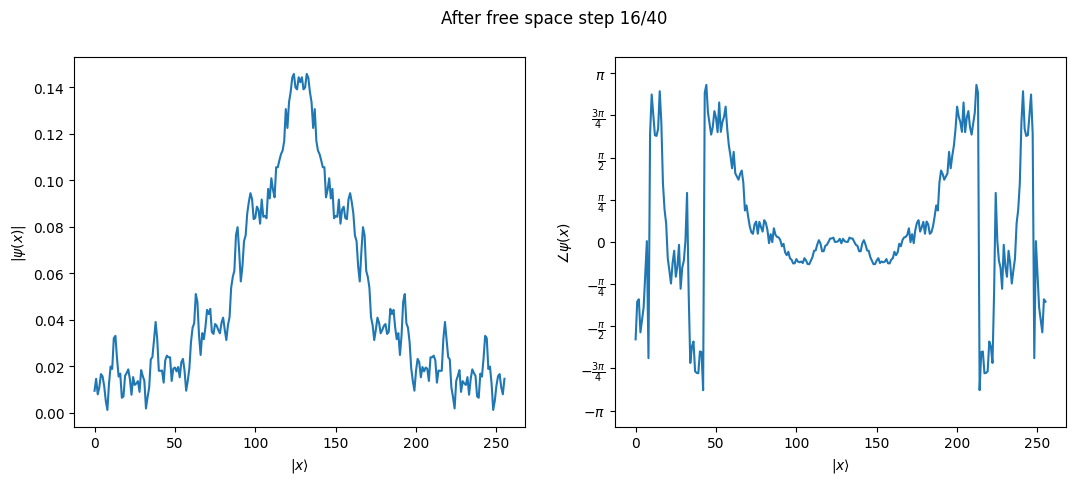

Plotting free space step 17/40


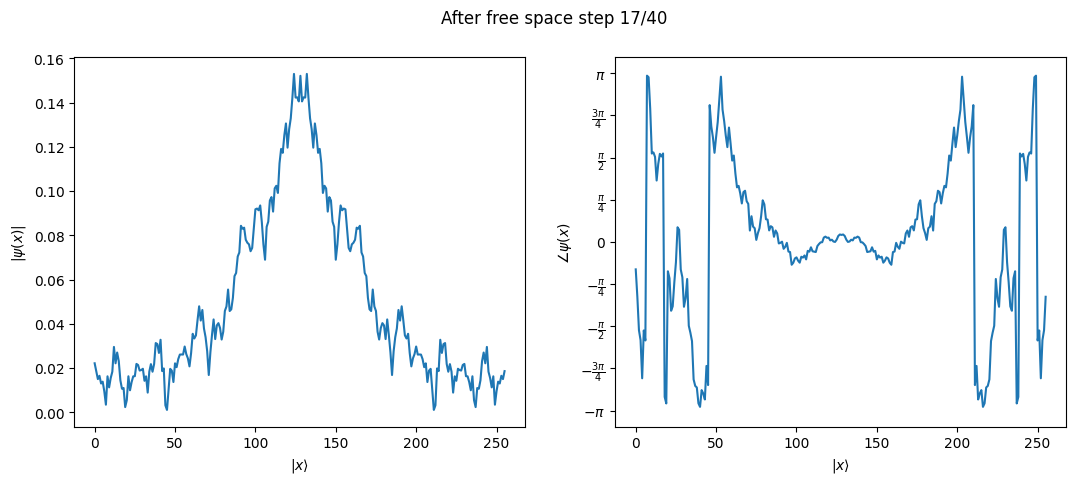

Plotting free space step 18/40


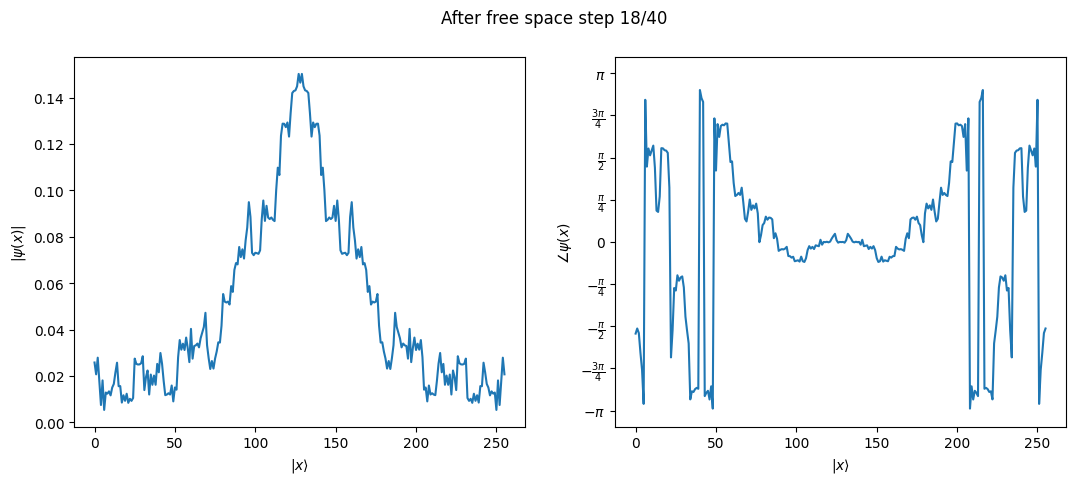

Plotting free space step 19/40


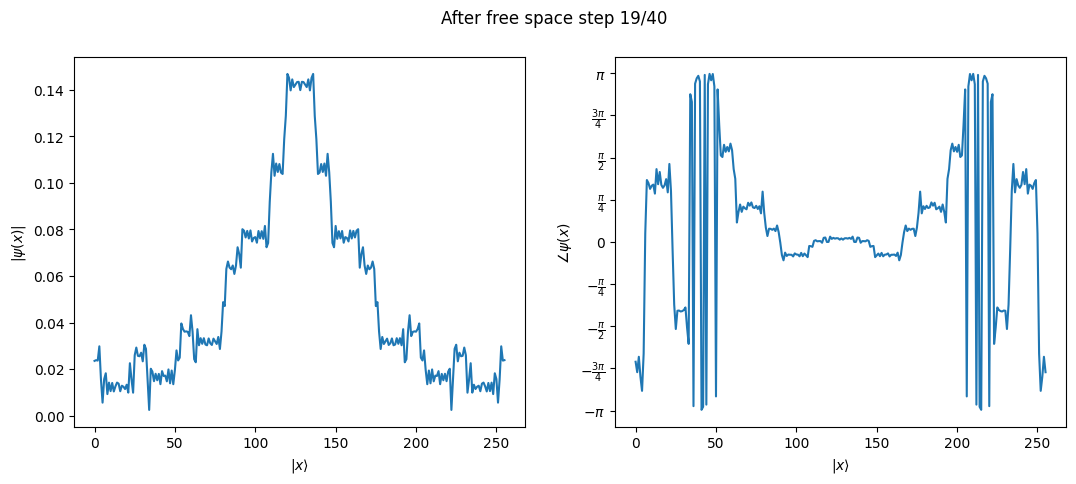

Plotting free space step 20/40


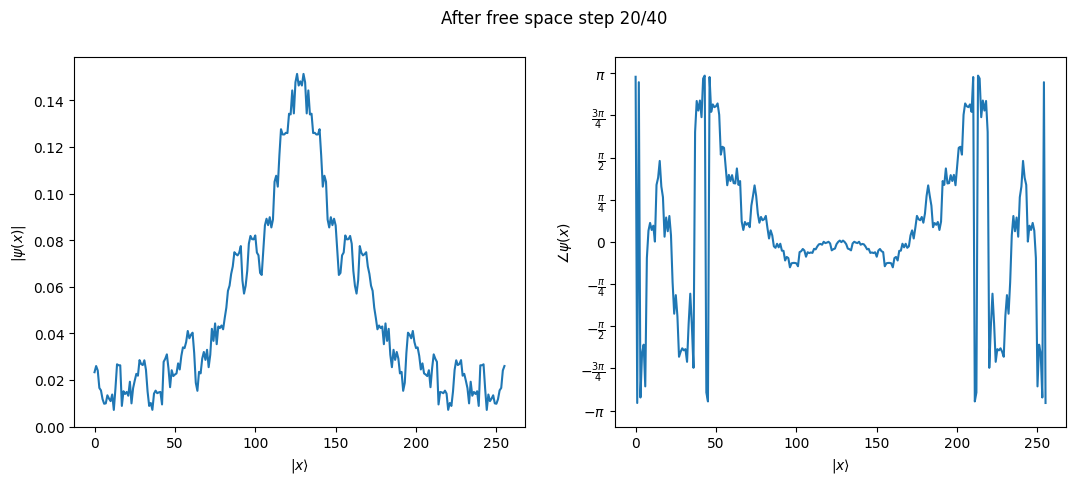

Plotting free space step 21/40


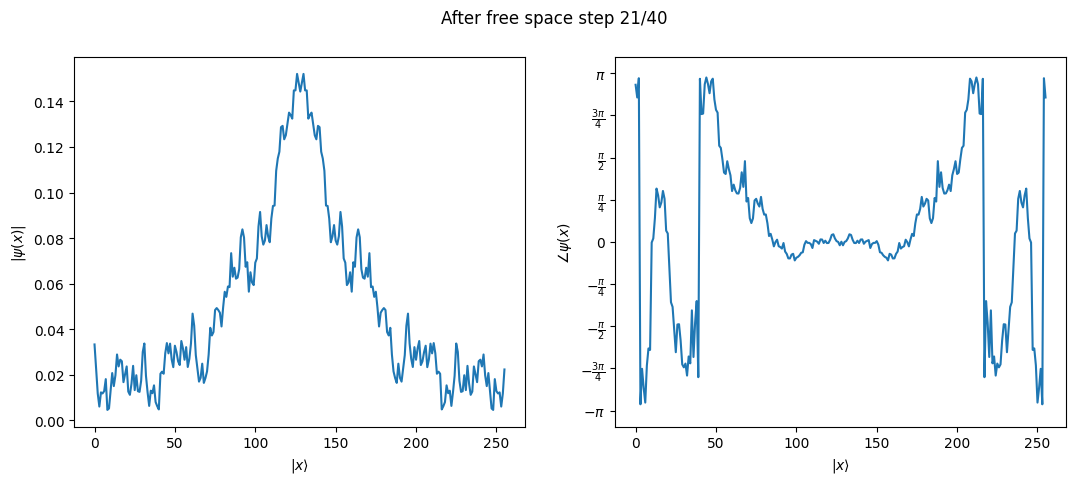

Plotting free space step 22/40


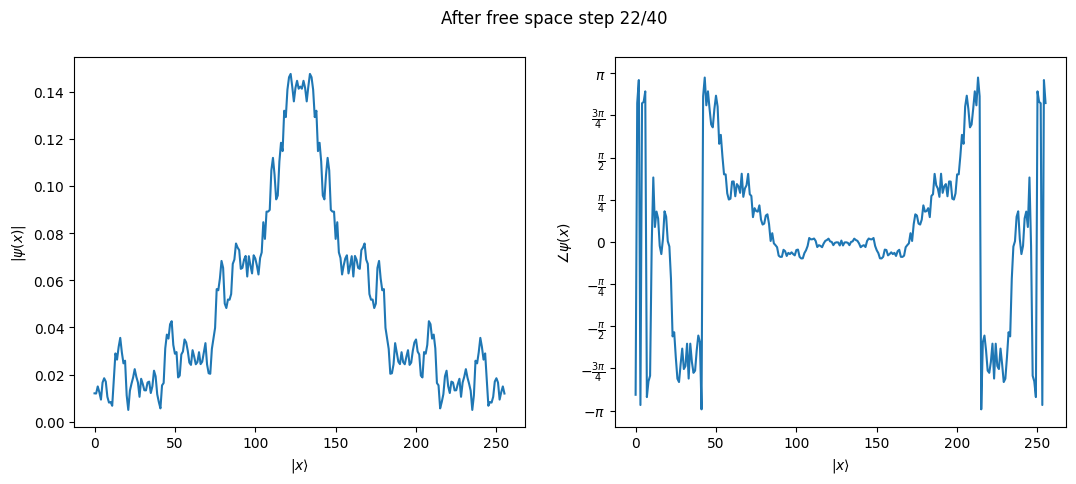

Plotting free space step 23/40


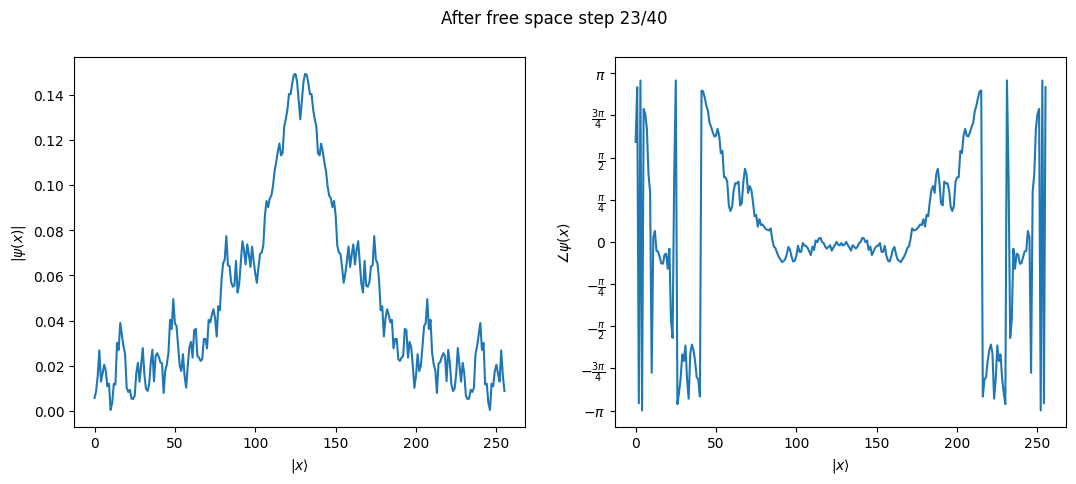

Plotting free space step 24/40


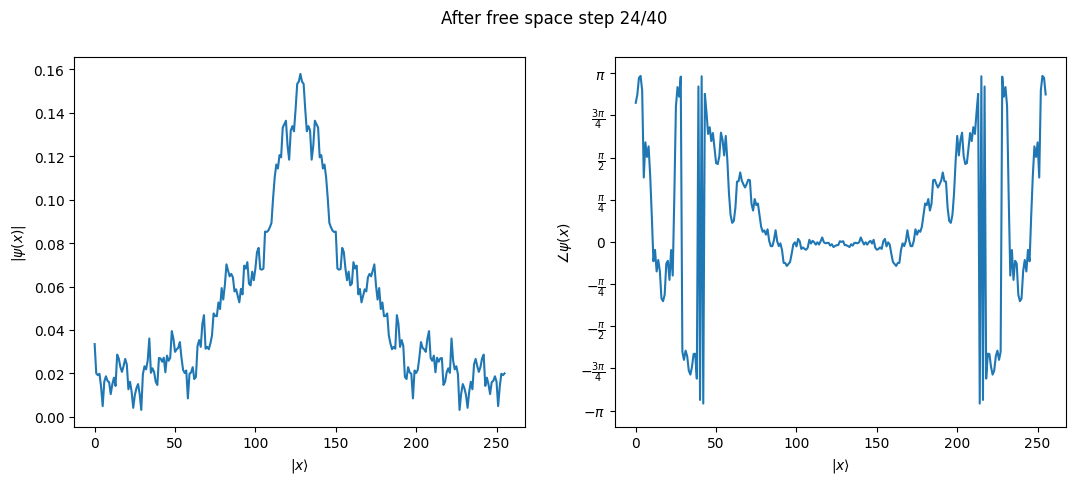

Plotting free space step 25/40


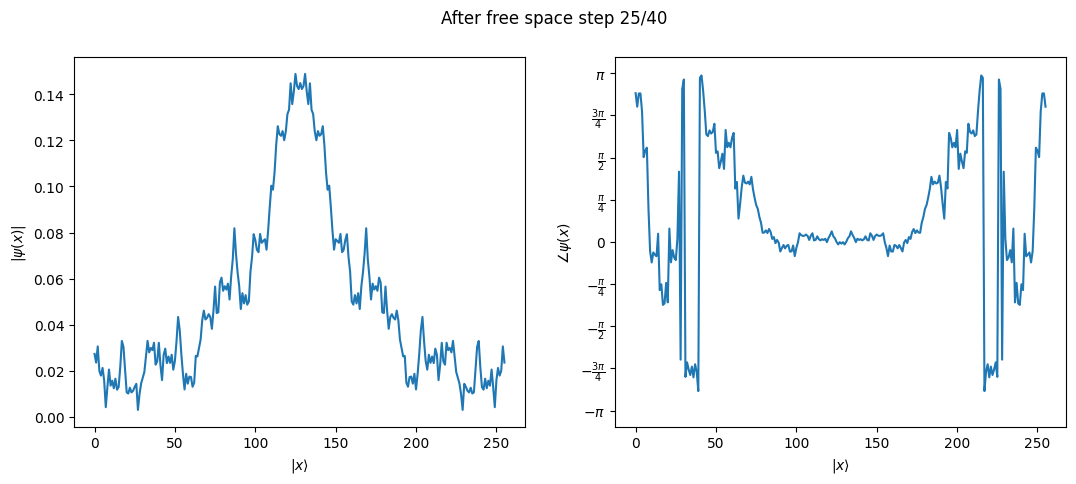

Plotting free space step 26/40


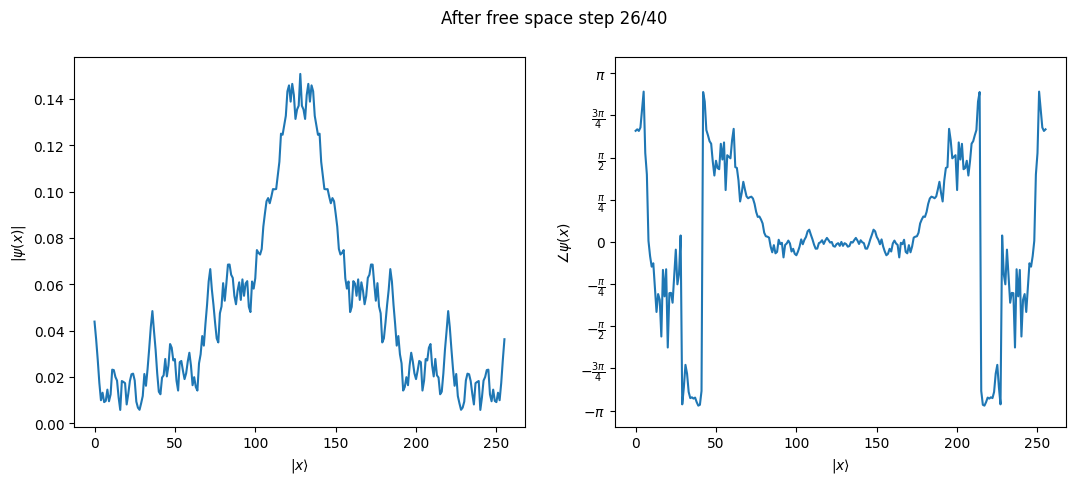

Plotting free space step 27/40


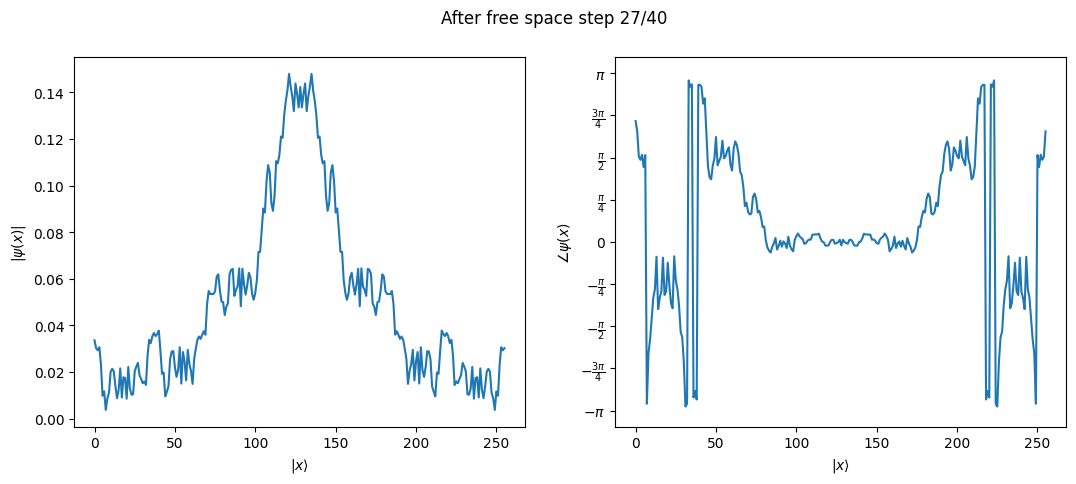

Plotting free space step 28/40


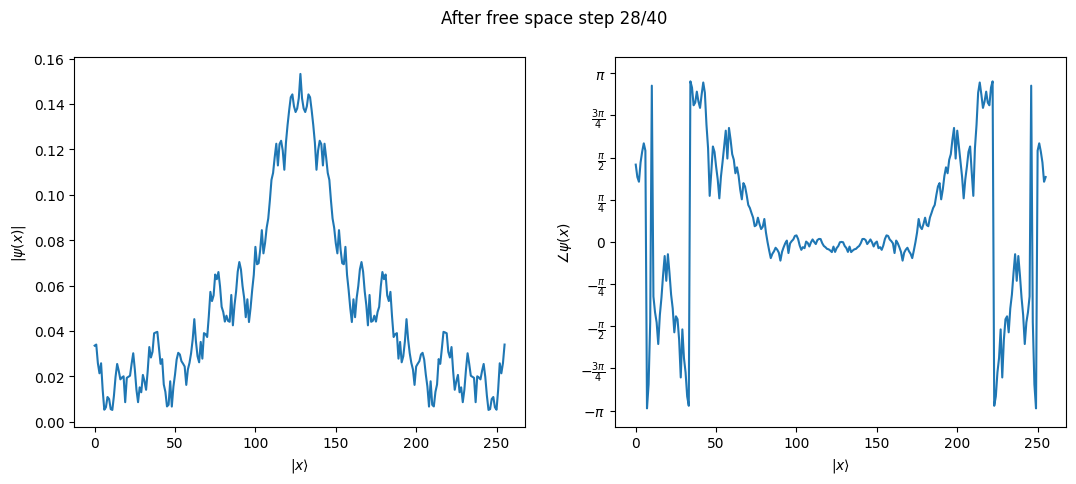

Plotting free space step 29/40


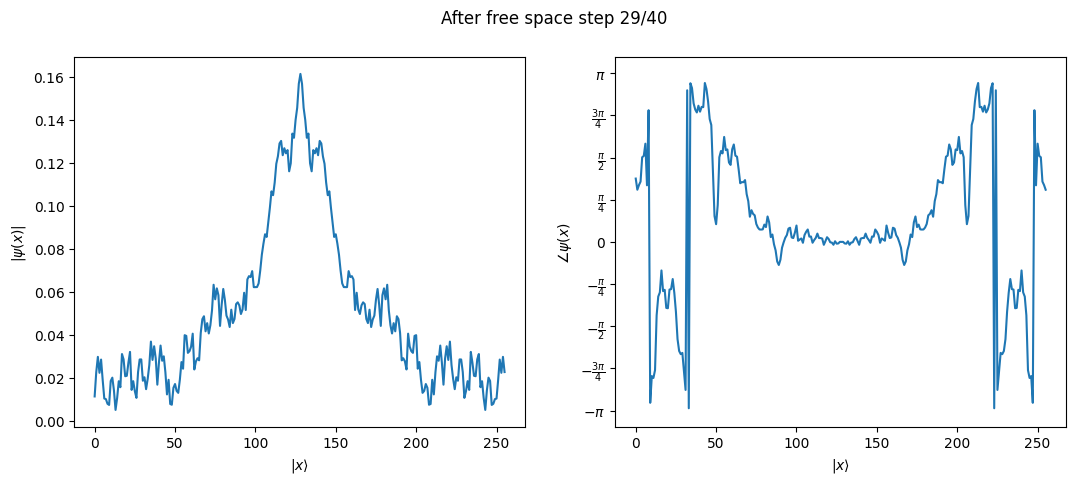

Plotting free space step 30/40


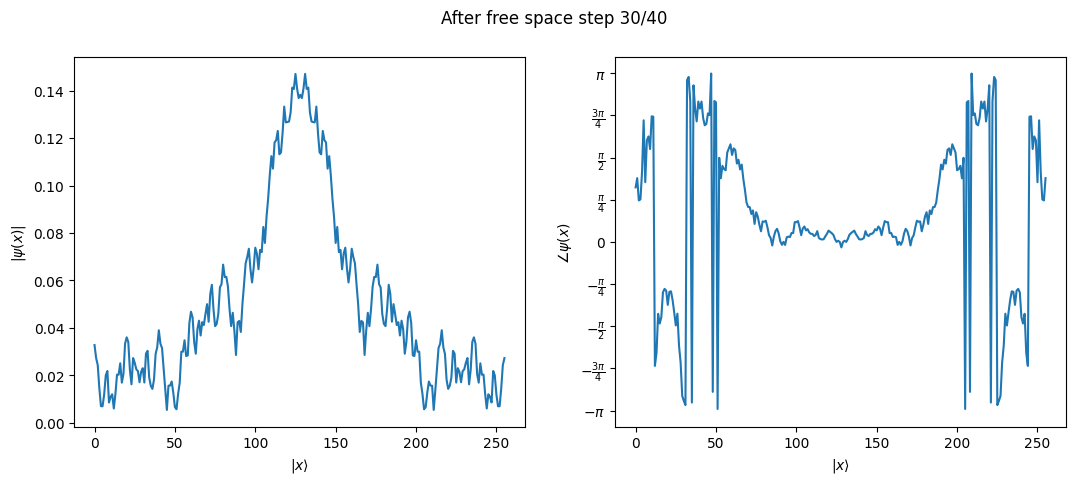

Plotting free space step 31/40


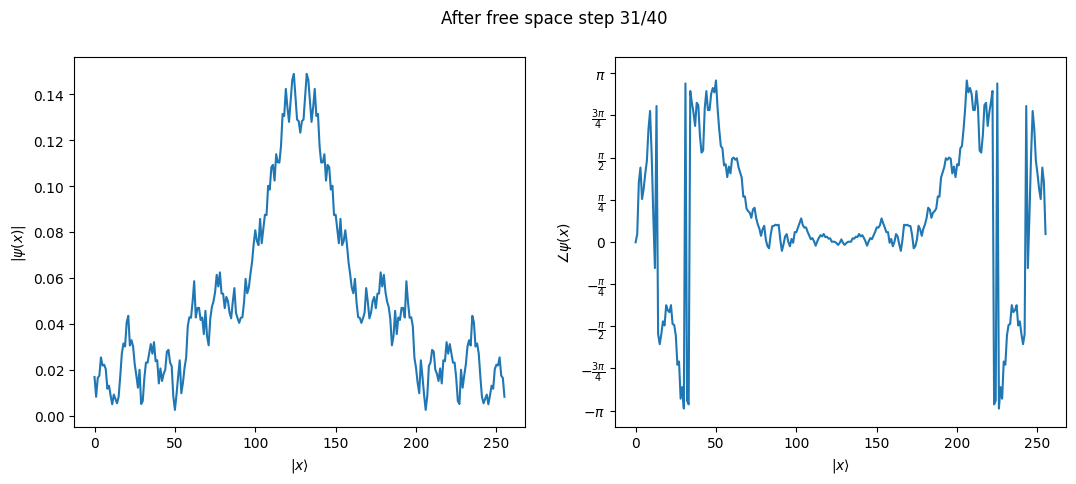

Plotting free space step 32/40


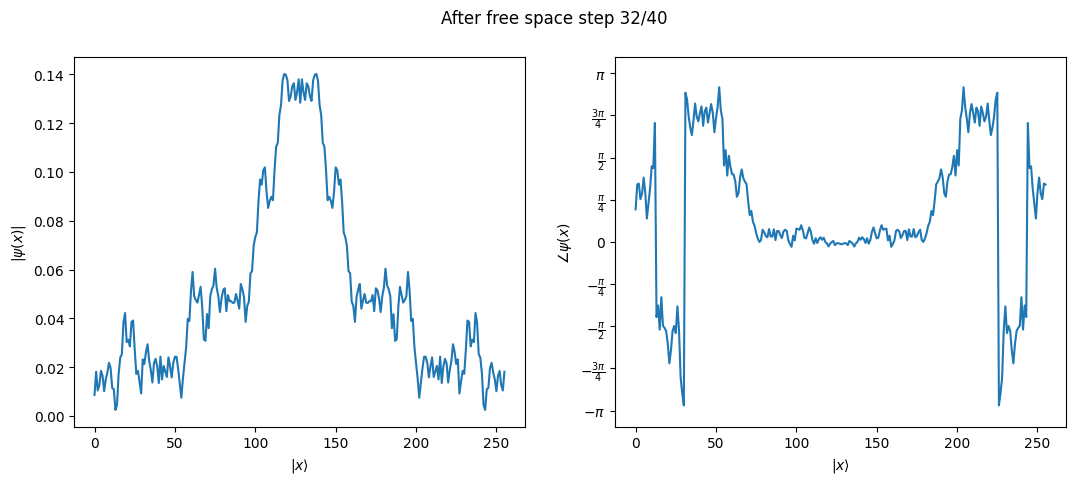

Plotting free space step 33/40


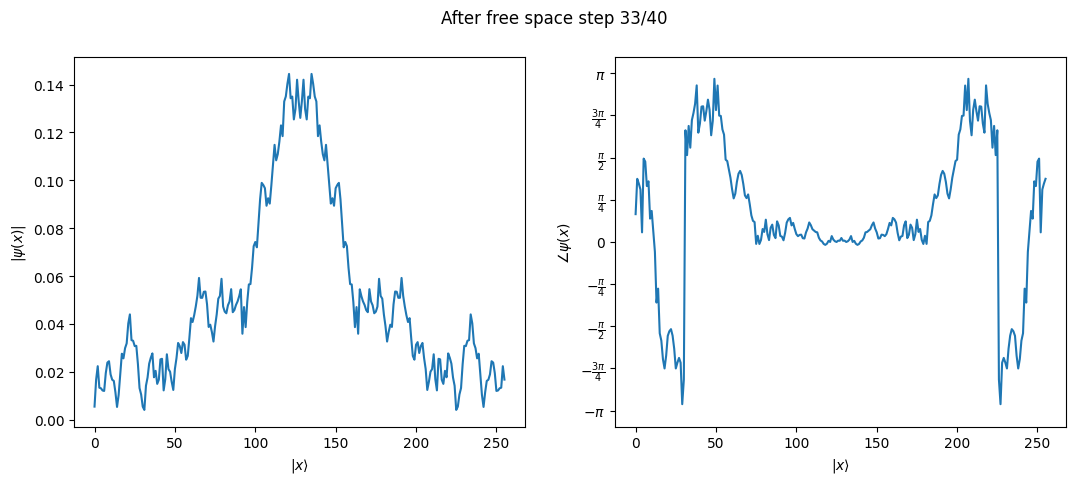

Plotting free space step 34/40


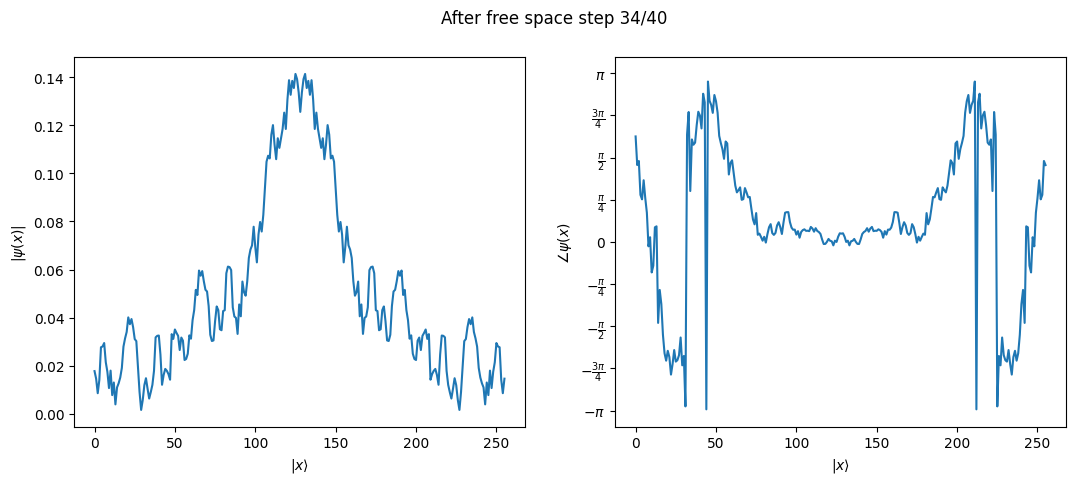

Plotting free space step 35/40


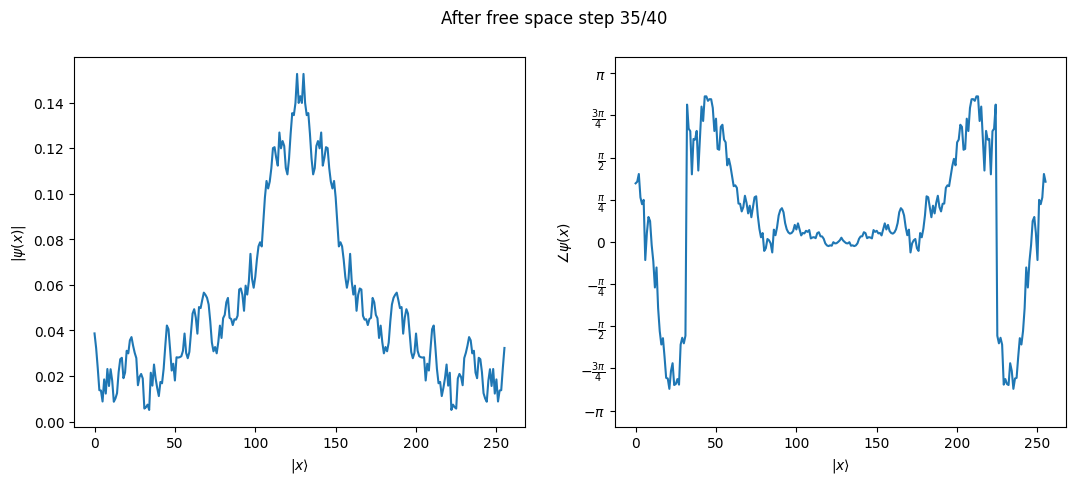

Plotting free space step 36/40


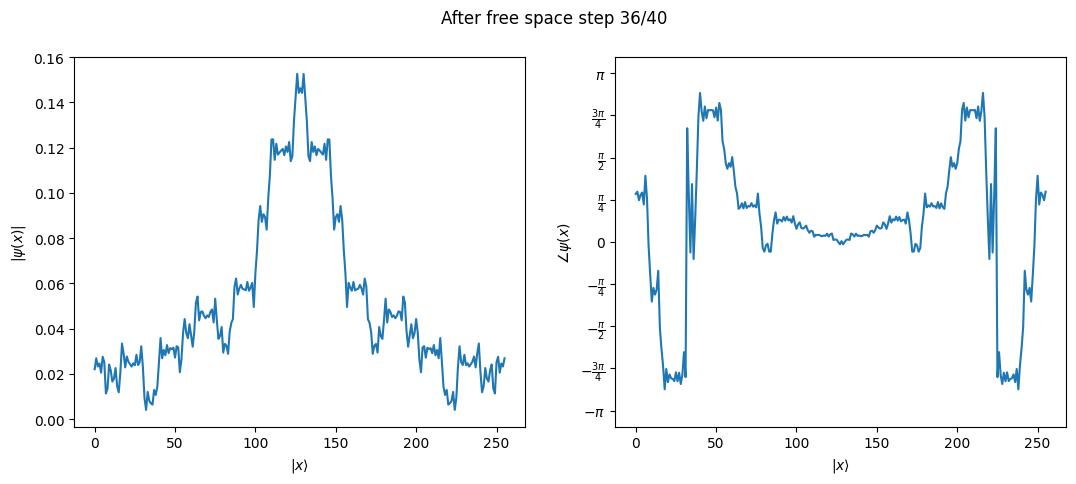

Plotting free space step 37/40


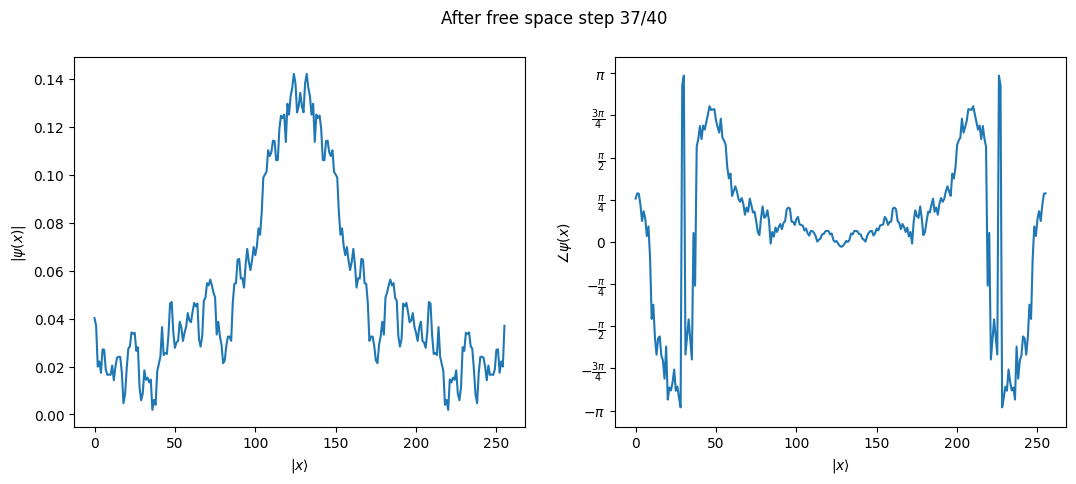

Plotting free space step 38/40


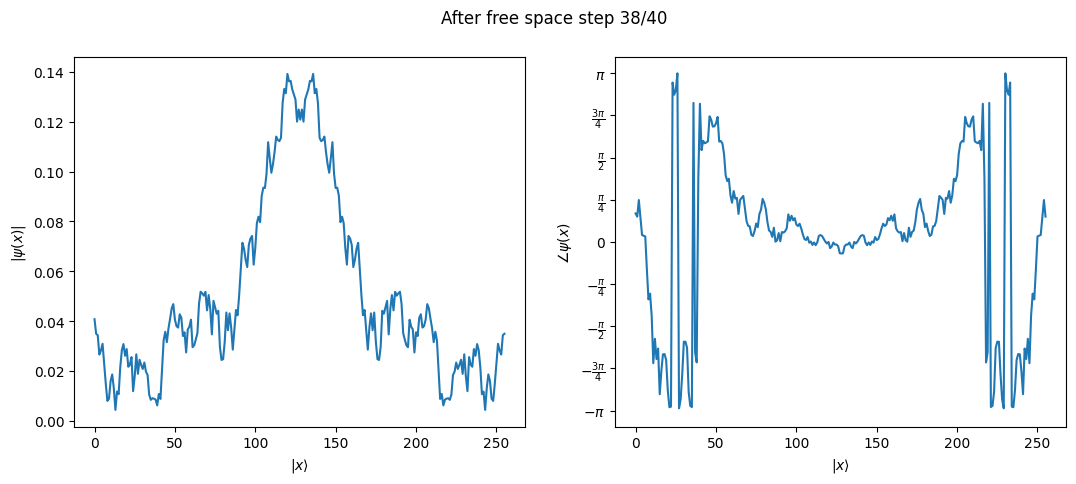

Plotting free space step 39/40


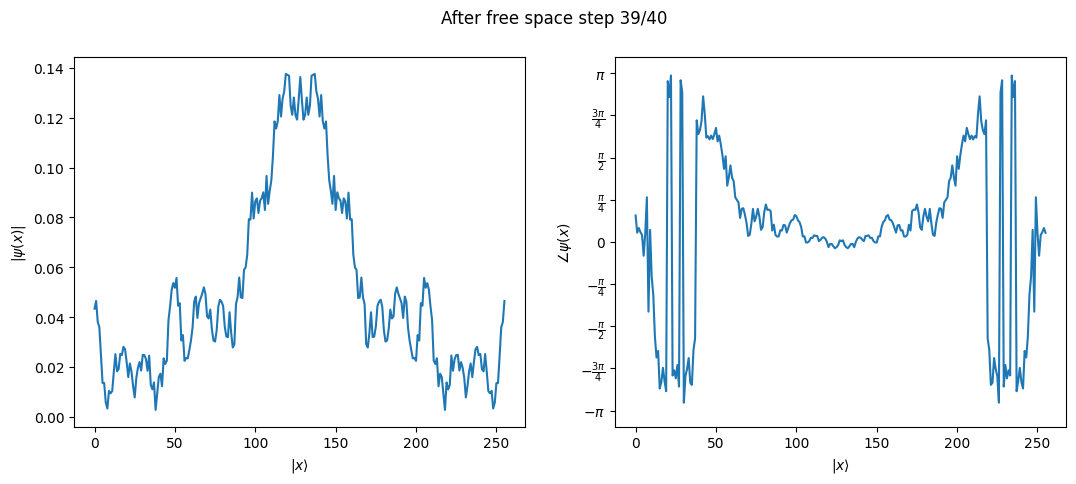

Plotting free space step 40/40


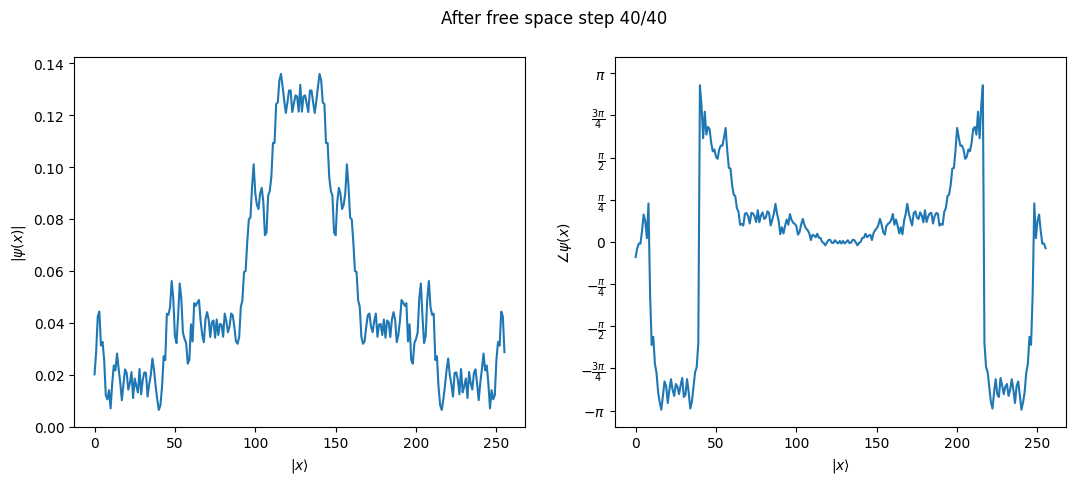

In [59]:
print("Plotting initial state")
plot_wavefunction(initial_statevector, plot_size_scale=1, normalize=True)
plt.suptitle("Initial state")
plt.show()

for i, statevector in enumerate(lens_statevectors):
    print(f"Plotting lens slice {i + 1}/{lens_slices}")
    plot_wavefunction(statevector, plot_size_scale=1, normalize=True)
    plt.suptitle(f"After lens slice {i + 1}/{lens_slices}")
    plt.show()

for i, statevector in enumerate(after_lens_statevectors):
    print(f"Plotting free space step {i + 1}/{num_of_steps_after_lens}")
    plot_wavefunction(statevector, plot_size_scale=1, normalize=True)
    plt.suptitle(f"After free space step {i + 1}/{num_of_steps_after_lens}")
    plt.show()